# Space Mission Dataset - Complete Exploratory Data Analysis (EDA)

**Project objective:** Perform a complete EDA of the Space Mission dataset, following the required five-phase process:

1. **Understand the Dataset**
2. **Data Preprocessing**
3. **Exploratory Data Analysis**
4. **Insights & Interpretation**
5. **Presentation Report**

**1. Import Libraries and Load the Dataset**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [4]:
path = "C:\\Users\\VEENA M\\OneDrive\\Desktop\\Space_Mission_EDA\\space_mission_data.csv"
df = pd.read_csv(path)

In [6]:
df

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


**2. Understand the Dataset**

In [7]:
print("Rows:", df.shape[0])
print("Columnss:", df.shape[1])
df.head()

Rows: 4324
Columnss: 9


,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [8]:
print("The columns include:")
df.columns.tolist()

The columns include:


['Unnamed: 0.1',
 'Unnamed: 0',
 'Organisation',
 'Location',
 'Date',
 'Detail',
 'Rocket_Status',
 'Price',
 'Mission_Status']

In [9]:
print("The datatype of each coulumn:")
df.dtypes

The datatype of each coulumn:


Unnamed: 0.1      int64
Unnamed: 0        int64
Organisation        str
Location            str
Date                str
Detail              str
Rocket_Status       str
Price               str
Mission_Status      str
dtype: object

In [10]:
print("The Dataset info:")
df.info()

The Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Unnamed: 0.1    4324 non-null   int64
 1   Unnamed: 0      4324 non-null   int64
 2   Organisation    4324 non-null   str  
 3   Location        4324 non-null   str  
 4   Date            4324 non-null   str  
 5   Detail          4324 non-null   str  
 6   Rocket_Status   4324 non-null   str  
 7   Price           964 non-null    str  
 8   Mission_Status  4324 non-null   str  
dtypes: int64(2), str(7)
memory usage: 830.6 KB


In [11]:
print("Cardinality of categorical columns:")
cardinality = pd.DataFrame({
    "Unique Values": df.nunique(dropna=False),
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean()*100).round(2)
}).sort_values("Missing Values", ascending=False)
cardinality

Cardinality of categorical columns:


,Unique Values,Missing Values,Missing %
Price,57,3360,77.71
Unnamed: 0.1,4324,0,0.00
Unnamed: 0,4324,0,0.00
Location,137,0,0.00
Organisation,56,0,0.00
Date,4319,0,0.00
Detail,4278,0,0.00
Rocket_Status,2,0,0.00
Mission_Status,4,0,0.00


In [12]:
print("Is Unnamed: 0.1 equals to Unnamed: 0 for all columns?", (df["Unnamed: 0.1"] == df["Unnamed: 0"]).all())

Is Unnamed: 0.1 equals to Unnamed: 0 for all columns? True


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Initial Findings:**
1. The Dataset contains 4324 rows and 9 columns.
2. Unnamed: 0.1 and Unnamed: 0 are exactly matched columns that do not provide any analytical value.
3. Price is stored as text and contains many missing values.
4. Categorical objects need type conversion to string.

**3. Data Preprocessing**
1. Remove unnecessary columns – Delete irrelevant or duplicate columns.
2. Handle duplicate records – Identify and remove duplicate rows.
3. Handle missing values – Remove, replace, or estimate missing data depending on the situation.
4. Correct data types – Convert columns to appropriate types such as numeric, datetime, or categorical.
5. Clean inconsistent data – Standardize spelling, capitalization, formats, and category names.
6. Handle outliers – Identify extreme values and decide whether to retain, transform, cap, or remove them.
7. Handle incorrect/invalid values – Detect errors and suspicious placeholder values such as 0, -1, or Unknown.
8. Clean text data – Remove unnecessary spaces, special characters, or inconsistent text formatting.
9. Feature extraction – Create useful features from existing columns, such as extracting Year and Month from Date.

In [14]:
data = df.copy()

In [15]:
#Remove the duplicate columns
data.drop(columns = ["Unnamed: 0.1","Unnamed: 0"], inplace = True) 

In [16]:
#Convert categorical objects into string
for col in ["Organisation", "Location", "Rocket_Status", "Mission_Status", "Detail"]:
    data[col] = data[col].astype("string").str.strip()

In [17]:
#Convert date of type str to date
data["Date"] = pd.to_datetime(data["Date"], errors = "coerce", utc = True, format = "mixed")
data["Date"].dtype

datetime64[us, UTC]

In [18]:
data["Date"].isna().sum()

np.int64(0)

In [19]:
#Convert string type of price to float 
data["Price"] = pd.to_numeric(data["Price"].astype("string").str.strip().str.replace(",", "", regex = False), errors = "coerce")
data.rename(columns = {"Price": "Price_Million_USD"}, inplace = True)
data["Price_Million_USD"].dtype

Float64Dtype()

In [20]:
#Extract additional data
data["Year"] = data["Date"].dt.year
data["Month"] = (data["Date"].dt.month_name()).astype("string")
data["Decade"] = (data["Year"]//10*10).astype("Int64")
data["Rocket_Name"] = data["Detail"].str.split("|").str[0].str.strip().astype("string")
data["Country"] = data["Location"].str.split(",").str[-1].str.strip().astype("string")

In [21]:
print("Check for potential placeholders:")
for col in ["Organisation", "Location", "Detail", "Rocket_Status", "Mission_Status"]:
    placeholders = data[col].astype("string").str.strip().str.lower().isin(["unknown", "na", "n/a", "none", "-", "missing", ""]).sum()
    print(f"{col}: {placeholders}")

Check for potential placeholders:
Organisation: 0
Location: 0
Detail: 0
Rocket_Status: 0
Mission_Status: 0


In [22]:
print("Total duplicate rows:", data.duplicated().sum())
duplicate_rows = data[data.duplicated(keep=False)]
display(duplicate_rows)
data.drop_duplicates(inplace=True)
print("Duplicates removed")

Total duplicate rows: 1


,Organisation,Location,Date,Detail,Rocket_Status,Price_Million_USD,Mission_Status,Year,Month,Decade,Rocket_Name,Country
792,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2008-11-05 00:15:00+00:00,Long March 2D | Shiyan-3 & Chuangxin-1(02),StatusActive,29.75,Success,2008,November,2000,Long March 2D,China
793,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2008-11-05 00:15:00+00:00,Long March 2D | Shiyan-3 & Chuangxin-1(02),StatusActive,29.75,Success,2008,November,2000,Long March 2D,China


Duplicates removed


**Handling Missing Values:**
 The dataset had 3,360 missing values in the Price_Million_USD column (77.71%). Instead of simply removing these records, the missing prices were estimated using an Extra Trees machine-learning model trained on the available price data.

Because many missing-price missions belonged to organizations/rockets with limited historical price information, a global median fallback was used for cases where the model produced unreliable estimates. The final dataset keeps the original observed prices and fills only the missing ones with estimated values.

In [23]:
display(data.shape)
display(data.head())
data.info()

(4323, 12)

,Organisation,Location,Date,Detail,Rocket_Status,Price_Million_USD,Mission_Status,Year,Month,Decade,Rocket_Name,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success,2020,August,2020,Falcon 9 Block 5,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,2020,August,2020,Long March 2D,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,<NA>,Success,2020,August,2020,Starship Prototype,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success,2020,July,2020,Proton-M/Briz-M,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.0,Success,2020,July,2020,Atlas V 541,USA


<class 'pandas.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   Organisation       4323 non-null   string             
 1   Location           4323 non-null   string             
 2   Date               4323 non-null   datetime64[us, UTC]
 3   Detail             4323 non-null   string             
 4   Rocket_Status      4323 non-null   string             
 5   Price_Million_USD  963 non-null    Float64            
 6   Mission_Status     4323 non-null   string             
 7   Year               4323 non-null   int32              
 8   Month              4323 non-null   string             
 9   Decade             4323 non-null   Int64              
 10  Rocket_Name        4323 non-null   string             
 11  Country            4323 non-null   string             
dtypes: Float64(1), Int64(1), datetime64[us, UTC](1), int32(1), strin

In [24]:
#Check for missing values
missing_values = pd.DataFrame({
    "Unique Values": data.nunique(dropna=False),
    "Missing Values": data.isna().sum(),
    "Missing %": (data.isna().mean()*100).round(2)
}).sort_values("Missing Values", ascending=False)
display(missing_values) 

,Unique Values,Missing Values,Missing %
Price_Million_USD,57,3360,77.72
Organisation,56,0,0.00
Date,4319,0,0.00
Location,137,0,0.00
Detail,4278,0,0.00
Rocket_Status,2,0,0.00
Mission_Status,4,0,0.00
Year,64,0,0.00
Month,12,0,0.00
Decade,8,0,0.00


In [25]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,4324.0,NaN,NaN,NaN,2161.5,1248.375611,0.0,1080.75,2161.5,3242.25,4323.0
Unnamed: 0,4324.0,NaN,NaN,NaN,2161.5,1248.375611,0.0,1080.75,2161.5,3242.25,4323.0
Organisation,4324,56,RVSN USSR,1777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,4324,137,"Site 31/6, Baikonur Cosmodrome, Kazakhstan",235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,4324,4319,"Wed Nov 05, 2008 00:15 UTC",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Detail,4324,4278,Cosmos-3MRB (65MRB) | BOR-5 Shuttle,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rocket_Status,4324,2,StatusRetired,3534,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,964,56,450.0,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mission_Status,4324,4,Success,3879,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
display(data["Price_Million_USD"].describe())
display(data["Price_Million_USD"].isnull().sum())
data["Price_Million_USD"].value_counts().head(15)

count         963.0
mean     153.921007
std      288.572876
min             5.3
25%            40.0
50%            62.0
75%           164.0
max          5000.0
Name: Price_Million_USD, dtype: Float64

np.int64(3360)

Price_Million_USD
450.0    136
200.0     75
40.0      55
62.0      41
30.8      38
109.0     37
50.0      34
64.68     34
29.75     32
90.0      32
41.8      31
48.5      26
29.15     25
31.0      22
29.0      22
Name: count, dtype: Int64

**Outlier Detection**

In [27]:
# Calculate IQR for Price
Q1 = data["Price_Million_USD"].quantile(0.25)
Q3 = data["Price_Million_USD"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 40.0
Q3: 164.0
IQR: 124.0
Lower Limit: -146.0
Upper Limit: 350.0


In [28]:
# Identify outliers
outliers = data[(data["Price_Million_USD"] < lower_limit) | (data["Price_Million_USD"] > upper_limit)]
print("Number of outliers:", len(outliers))
display(outliers[["Organisation", "Location", "Date", "Detail", "Price_Million_USD", "Mission_Status"]].sort_values("Price_Million_USD", ascending=False))

Number of outliers: 151


,Organisation,Location,Date,Detail,Price_Million_USD,Mission_Status
1916,RVSN USSR,"Site 110/37, Baikonur Cosmodrome, Kazakhstan",1988-11-15 03:00:00+00:00,Energiya/Buran | Buran,5000.0,Success
2000,RVSN USSR,"Site 250, Baikonur Cosmodrome, Kazakhstan",1987-05-15 17:30:00+00:00,Energiya/Polyus | Polyus Space Station,5000.0,Success
3545,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1969-07-16 13:32:00+00:00,Saturn V | Apollo 11,1160.0,Success
3475,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1970-04-11 19:13:00+00:00,Saturn V | Apollo 13,1160.0,Success
3180,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1972-12-19 19:24:00+00:00,Saturn V | Apollo 17,1160.0,Success
...,...,...,...,...,...,...
2153,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1985-01-24 19:50:00+00:00,Space Shuttle Discovery | STS-51-C,450.0,Success
2141,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1985-04-12 13:59:00+00:00,Space Shuttle Discovery | STS-51-D,450.0,Success
2371,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1981-11-12 15:09:00+00:00,Space Shuttle Columbia | STS-2,450.0,Success
2408,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1981-04-12 12:00:00+00:00,Space Shuttle Columbia | STS-1,450.0,Success


**1. Univariate Analysis**

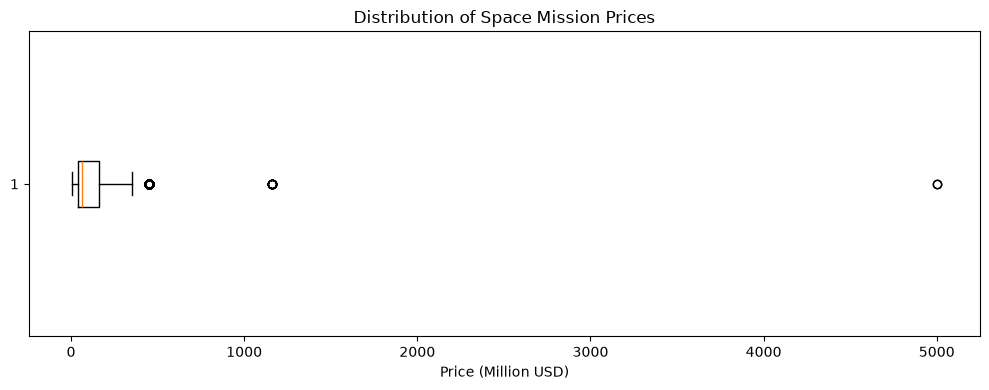

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.boxplot(data["Price_Million_USD"].dropna(), orientation="horizontal")
plt.title("Distribution of Space Mission Prices")
plt.xlabel("Price (Million USD)")
plt.tight_layout()
plt.show()

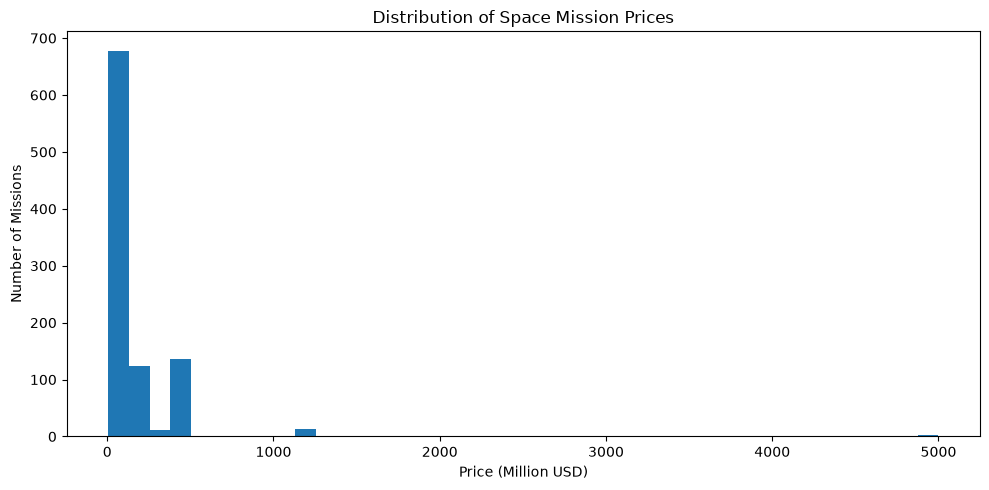

In [30]:
plt.figure(figsize=(10, 5))
plt.hist(data["Price_Million_USD"].dropna(), bins=40)
plt.title("Distribution of Space Mission Prices")
plt.xlabel("Price (Million USD)")
plt.ylabel("Number of Missions")
plt.tight_layout()
plt.show()

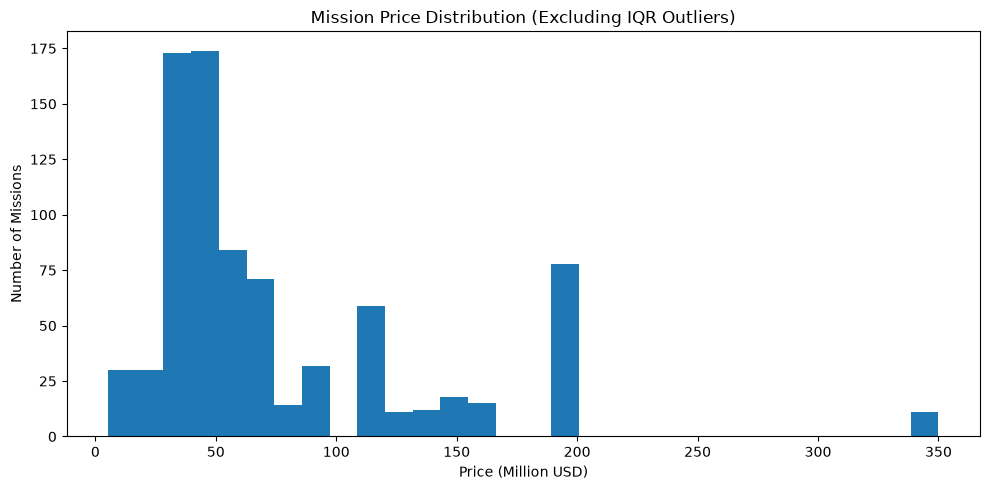

In [31]:
# Price distribution excluding extreme outliers
price_without_outliers = data[data["Price_Million_USD"] <= upper_limit]["Price_Million_USD"].dropna()
plt.figure(figsize=(10, 5))
plt.hist(price_without_outliers, bins=30)
plt.title("Mission Price Distribution (Excluding IQR Outliers)")
plt.xlabel("Price (Million USD)")
plt.ylabel("Number of Missions")
plt.tight_layout()
plt.show()

In [32]:
high_price = data[data["Price_Million_USD"] > 350].sort_values("Price_Million_USD", ascending=False)
display(high_price[["Organisation", "Country", "Year", "Rocket_Name", "Detail", "Price_Million_USD", "Mission_Status"]])

,Organisation,Country,Year,Rocket_Name,Detail,Price_Million_USD,Mission_Status
1916,RVSN USSR,Kazakhstan,1988,Energiya/Buran,Energiya/Buran | Buran,5000.0,Success
2000,RVSN USSR,Kazakhstan,1987,Energiya/Polyus,Energiya/Polyus | Polyus Space Station,5000.0,Success
3545,NASA,USA,1969,Saturn V,Saturn V | Apollo 11,1160.0,Success
3475,NASA,USA,1970,Saturn V,Saturn V | Apollo 13,1160.0,Success
3180,NASA,USA,1972,Saturn V,Saturn V | Apollo 17,1160.0,Success
...,...,...,...,...,...,...,...
2153,NASA,USA,1985,Space Shuttle Discovery,Space Shuttle Discovery | STS-51-C,450.0,Success
2141,NASA,USA,1985,Space Shuttle Discovery,Space Shuttle Discovery | STS-51-D,450.0,Success
2371,NASA,USA,1981,Space Shuttle Columbia,Space Shuttle Columbia | STS-2,450.0,Success
2408,NASA,USA,1981,Space Shuttle Columbia,Space Shuttle Columbia | STS-1,450.0,Success


In [33]:
high_price["Organisation"].value_counts()

Organisation
NASA         149
RVSN USSR      2
Name: count, dtype: int64[pyarrow]

In [34]:
high_price["Price_Million_USD"].value_counts()

Price_Million_USD
450.0     136
1160.0     13
5000.0      2
Name: count, dtype: Int64

In [35]:
org_price = (data[data["Price_Million_USD"].notna()].groupby("Organisation")["Price_Million_USD"].agg(["count", "mean", "median", "max"]).sort_values("median", ascending=False))
display(org_price.head(15))

,count,mean,median,max
Organisation,,,,
RVSN USSR,2,5000.0,5000.0,5000.0
NASA,149,511.946309,450.0,1160.0
Arianespace,96,170.260417,200.0,200.0
Boeing,7,177.285714,164.0,350.0
ULA,98,151.0,123.0,350.0
ILS,13,101.538462,109.0,153.0
MHI,37,95.472973,90.0,112.5
US Air Force,26,59.650769,59.0,63.23
SpaceX,99,54.989899,56.5,90.0


In [36]:
mission_status = data["Mission_Status"].value_counts()
print(mission_status)

Mission_Status
Success              3878
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64[pyarrow]


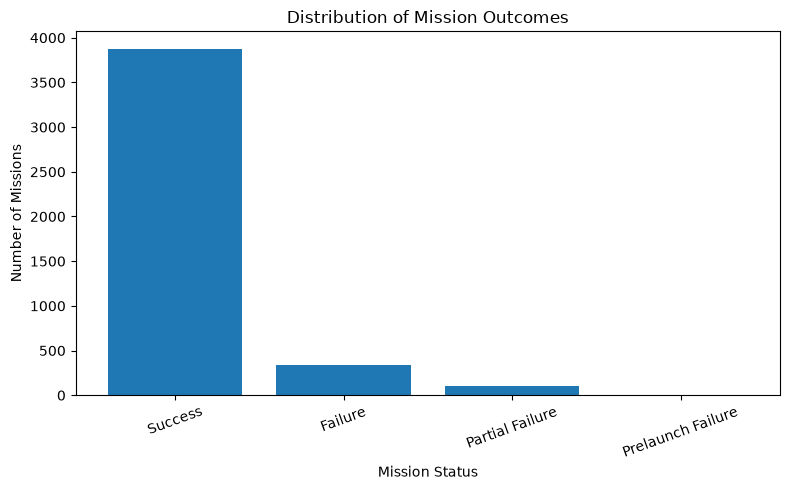

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(mission_status.index, mission_status.values)
plt.title("Distribution of Mission Outcomes")
plt.xlabel("Mission Status")
plt.ylabel("Number of Missions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [38]:
mission_percentage = (data["Mission_Status"].value_counts(normalize=True).mul(100).round(2))
print(mission_percentage)

Mission_Status
Success              89.71
Failure               7.84
Partial Failure       2.36
Prelaunch Failure     0.09
Name: proportion, dtype: double[pyarrow]


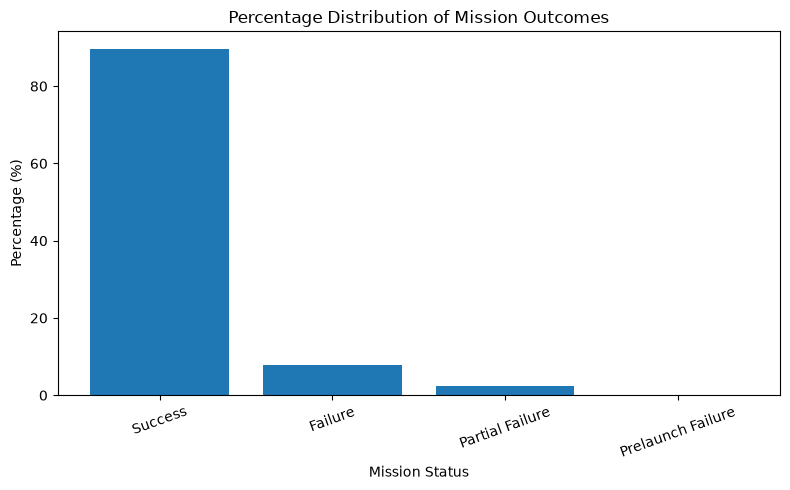

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(mission_percentage.index, mission_percentage.values)
plt.title("Percentage Distribution of Mission Outcomes")
plt.xlabel("Mission Status")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [40]:
org_counts = data["Organisation"].value_counts()
print(org_counts.head(15))

Organisation
RVSN USSR           1777
Arianespace          279
General Dynamics     251
CASC                 250
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Name: count, dtype: int64[pyarrow]


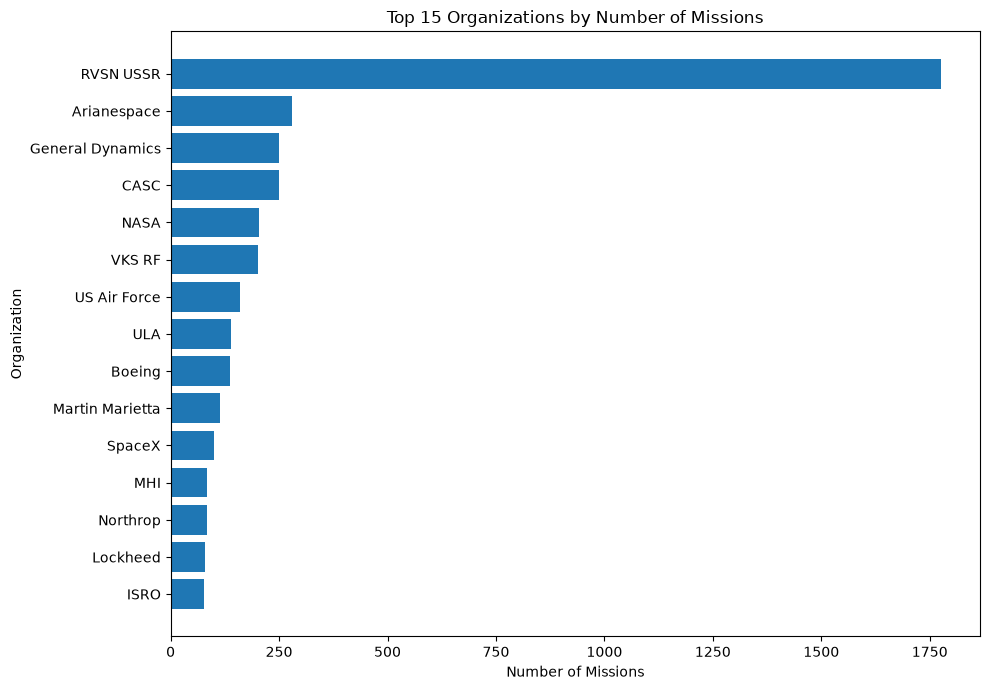

In [41]:
top_org = org_counts.head(15).sort_values()
plt.figure(figsize=(10, 7))
plt.barh(top_org.index, top_org.values)
plt.title("Top 15 Organizations by Number of Missions")
plt.xlabel("Number of Missions")
plt.ylabel("Organization")
plt.tight_layout()
plt.show()

In [42]:
country_counts = data["Country"].value_counts()
print(country_counts.head(15))

Country
Russia           1395
USA              1344
Kazakhstan        701
France            303
China             267
Japan             126
India              76
Pacific Ocean      36
New Zealand        13
Iran               13
Israel             11
Kenya               9
Australia           6
North Korea         5
New Mexico          4
Name: count, dtype: int64[pyarrow]


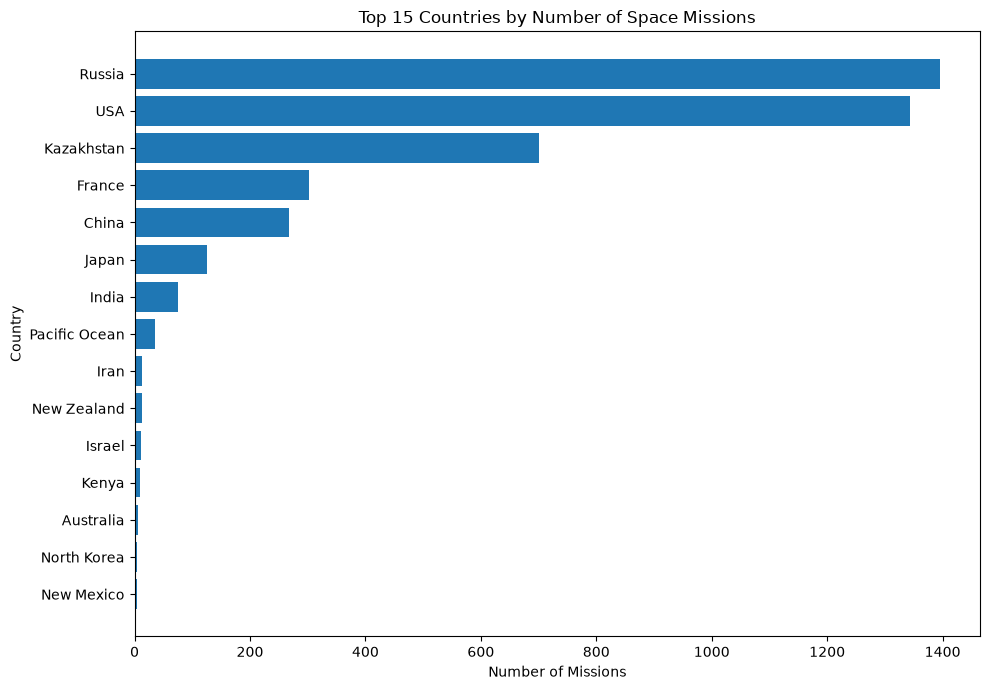

In [43]:
top_countries = country_counts.head(15).sort_values()
plt.figure(figsize=(10, 7))
plt.barh(top_countries.index, top_countries.values)
plt.title("Top 15 Countries by Number of Space Missions")
plt.xlabel("Number of Missions")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [44]:
yearly_missions = (data.groupby("Year").size())
display(yearly_missions)

Year
1957      3
1958     28
1959     20
1960     39
1961     52
       ... 
2016     90
2017     92
2018    117
2019    109
2020     63
Length: 64, dtype: int64

In [45]:
yearly_success = (data.groupby("Year")["Mission_Status"].apply(lambda x: (x == "Success").mean() * 100))
display(yearly_success)

Year
1957    66.666667
1958    21.428571
1959    40.000000
1960    48.717949
1961    61.538462
          ...    
2016    95.555556
2017    91.304348
2018    96.581197
2019    91.743119
2020    90.476190
Name: Mission_Status, Length: 64, dtype: float64

**2. Bivariate Analysis**

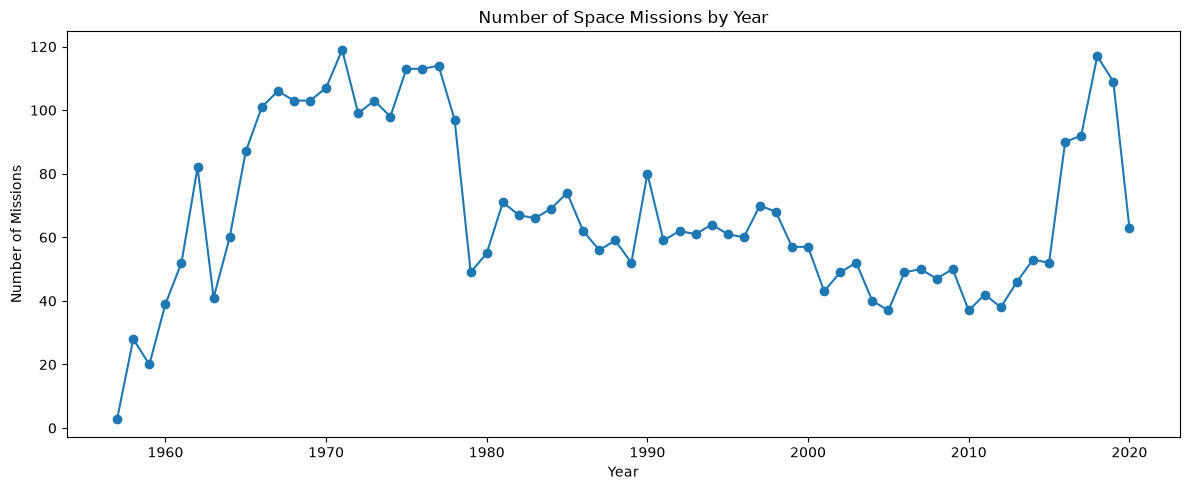

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(yearly_missions.index, yearly_missions.values, marker="o")
plt.title("Number of Space Missions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Missions")
plt.tight_layout()
plt.show()

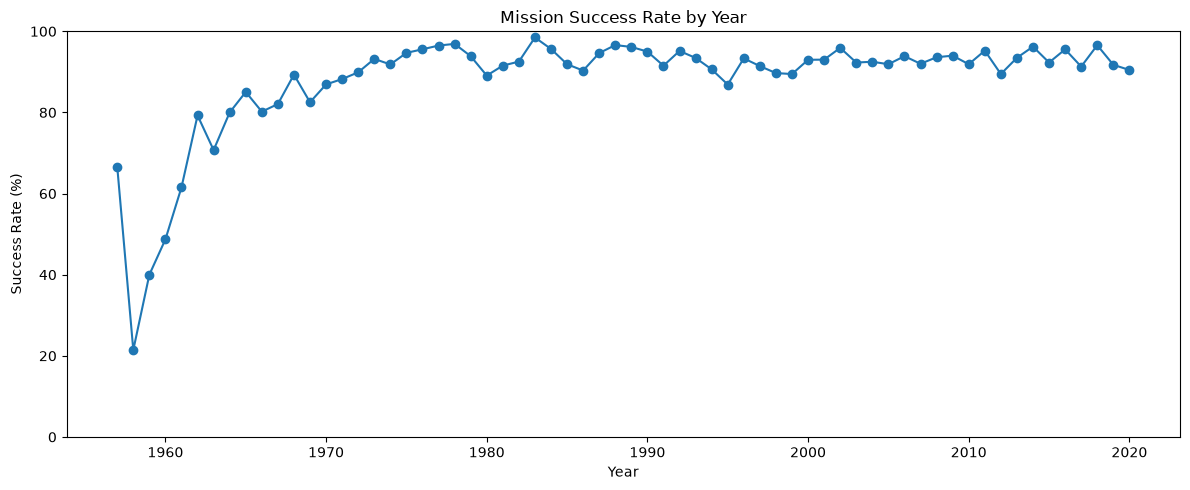

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(yearly_success.index, yearly_success.values, marker="o")
plt.title("Mission Success Rate by Year")
plt.xlabel("Year")
plt.ylabel("Success Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [48]:
decade_analysis = (data.groupby("Decade").agg(Missions=("Mission_Status", "size"), Success_Rate=("Mission_Status", lambda x: (x == "Success").mean() * 100)))
display(decade_analysis.round(2))

,Missions,Success_Rate
Decade,,
1950,51,31.37
1960,774,79.07
1970,1012,92.69
1980,631,93.66
1990,642,91.74
2000,474,93.25
2010,676,93.64
2020,63,90.48


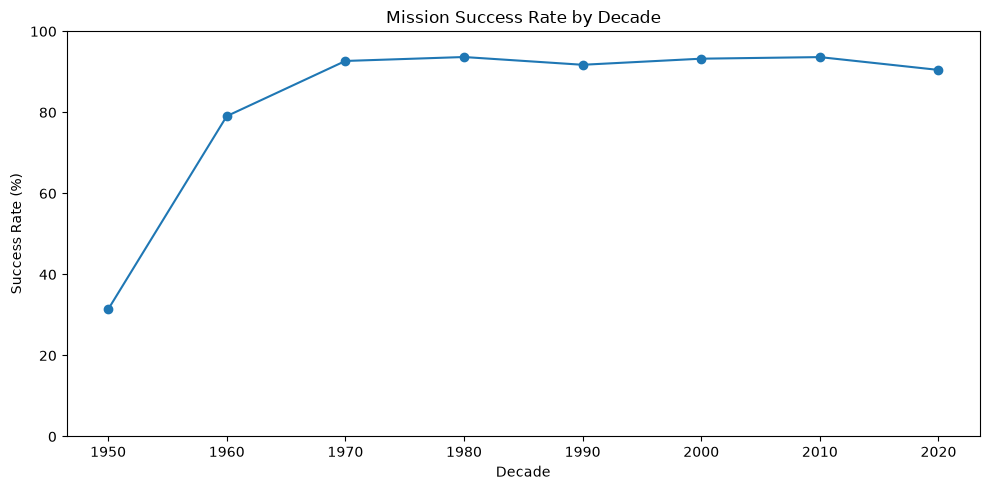

In [49]:
plt.figure(figsize=(10, 5))
plt.plot(decade_analysis.index, decade_analysis["Success_Rate"], marker="o")
plt.title("Mission Success Rate by Decade")
plt.xlabel("Decade")
plt.ylabel("Success Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [50]:
org_success = (data.groupby("Organisation").agg(
        Missions=("Mission_Status", "size"),
        Successes=("Mission_Status", lambda x: (x == "Success").sum())))
org_success["Success_Rate"] = (org_success["Successes"] / org_success["Missions"] * 100)
org_success = org_success.sort_values("Missions", ascending=False)
display(org_success.head(15).round(2))

,Missions,Successes,Success_Rate
Organisation,,,
RVSN USSR,1777,1614,90.83
Arianespace,279,269,96.42
General Dynamics,251,203,80.88
CASC,250,230,92.0
NASA,203,186,91.63
VKS RF,201,188,93.53
US Air Force,161,129,80.12
ULA,140,139,99.29
Boeing,136,131,96.32


In [51]:
org_success_20 = org_success[org_success["Missions"] >= 20].sort_values("Success_Rate", ascending=False)
display(org_success_20)

,Missions,Successes,Success_Rate
Organisation,,,
ULA,140,139,99.285714
ILS,46,45,97.826087
Arianespace,279,269,96.415771
Boeing,136,131,96.323529
Kosmotras,22,21,95.454545
MHI,84,80,95.238095
SpaceX,100,94,94.0
Lockheed,79,74,93.670886
VKS RF,201,188,93.532338


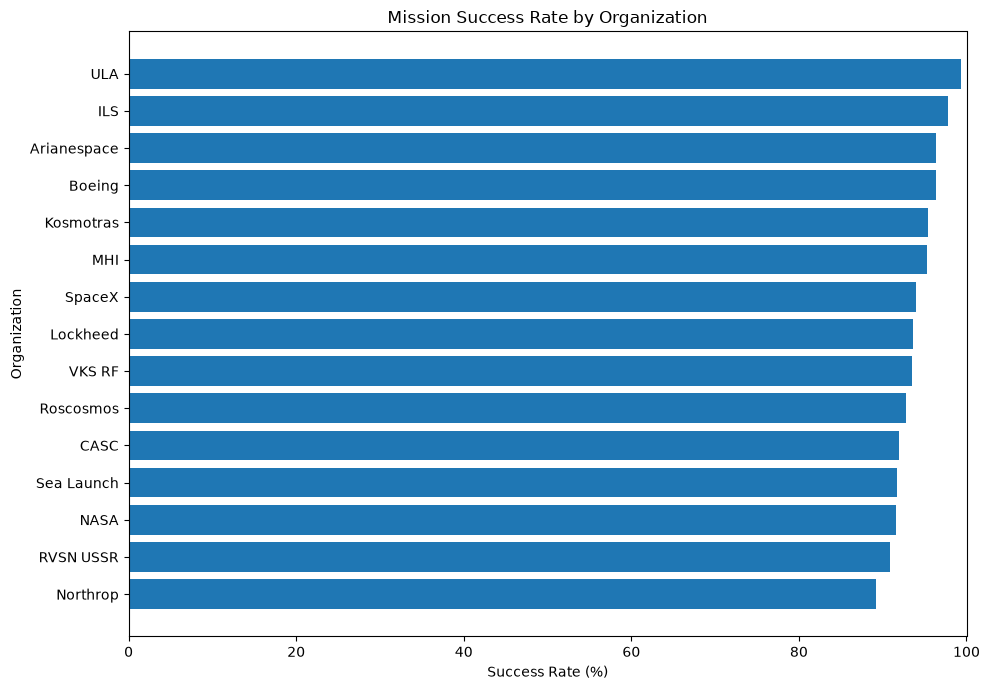

In [52]:
top_org_success = org_success_20.head(15).sort_values("Success_Rate")
plt.figure(figsize=(10, 7))
plt.barh(top_org_success.index, top_org_success["Success_Rate"])
plt.title("Mission Success Rate by Organization")
plt.xlabel("Success Rate (%)")
plt.ylabel("Organization")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [53]:
country_success = (data.groupby("Country").agg(
        Missions=("Mission_Status", "size"),
        Successes=("Mission_Status", lambda x: (x == "Success").sum())))
country_success["Success_Rate"] = (country_success["Successes"] / country_success["Missions"] * 100)
country_success_20 = country_success[country_success["Missions"] >= 20].sort_values("Success_Rate", ascending=False)
display(country_success_20.round(2))

,Missions,Successes,Success_Rate
Country,,,
France,303,285,94.06
Russia,1395,1303,93.41
Pacific Ocean,36,33,91.67
China,267,242,90.64
Japan,126,113,89.68
USA,1344,1186,88.24
Kazakhstan,701,608,86.73
India,76,63,82.89


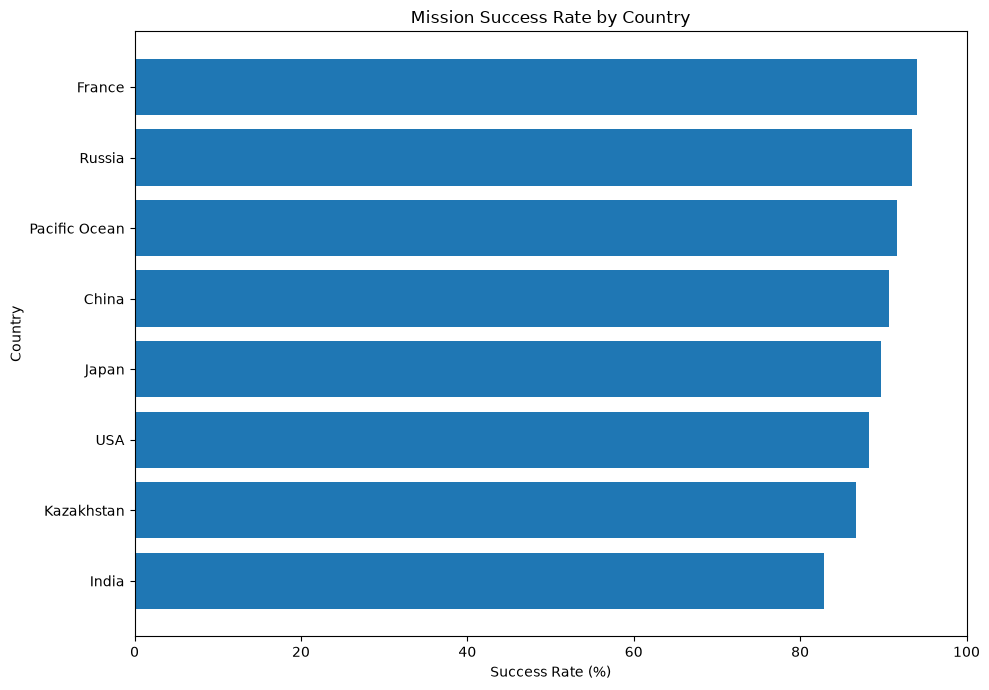

In [54]:
country_plot = country_success_20.head(15).sort_values("Success_Rate")
plt.figure(figsize=(10, 7))
plt.barh(country_plot.index, country_plot["Success_Rate"])
plt.title("Mission Success Rate by Country")
plt.xlabel("Success Rate (%)")
plt.ylabel("Country")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [55]:
rocket_success = (data.groupby("Rocket_Status").agg(
        Missions=("Mission_Status", "size"),
        Successes=("Mission_Status", lambda x: (x == "Success").sum())))
rocket_success["Success_Rate"] = (rocket_success["Successes"] / rocket_success["Missions"] * 100)
display(rocket_success.round(2))

,Missions,Successes,Success_Rate
Rocket_Status,,,
StatusActive,789,735,93.16
StatusRetired,3534,3143,88.94


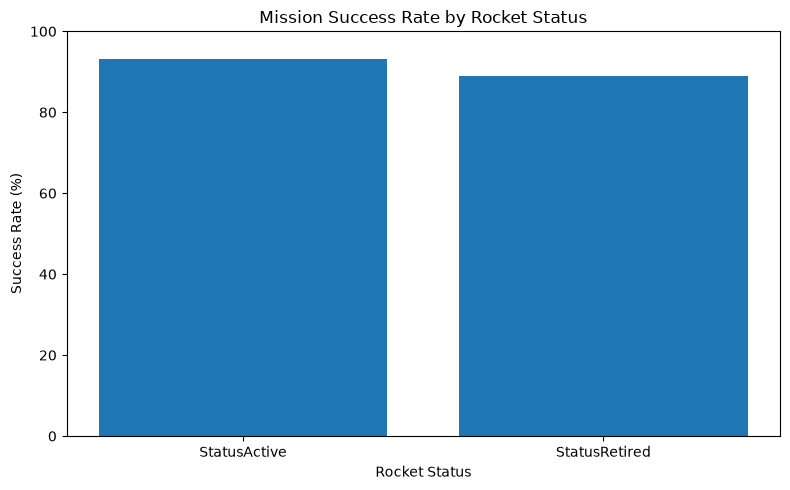

In [56]:
plt.figure(figsize=(8, 5))
plt.bar(
    rocket_success.index,
    rocket_success["Success_Rate"]
)
plt.title("Mission Success Rate by Rocket Status")
plt.xlabel("Rocket Status")
plt.ylabel("Success Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [57]:
price_year = (
    data[data["Price_Million_USD"].notna()]
    .groupby("Year")
    ["Price_Million_USD"]
    .agg(["count", "mean", "median"])
)
display(price_year.tail(20))

,count,mean,median
Year,,,
2001,10,290.7,450.0
2002,17,185.585882,90.0
2003,20,80.5115,41.8
2004,17,92.735882,48.5
2005,15,95.793333,40.0
2006,27,138.605926,90.0
2007,29,125.695172,69.7
2008,27,133.451852,64.68
2009,31,180.287097,123.0


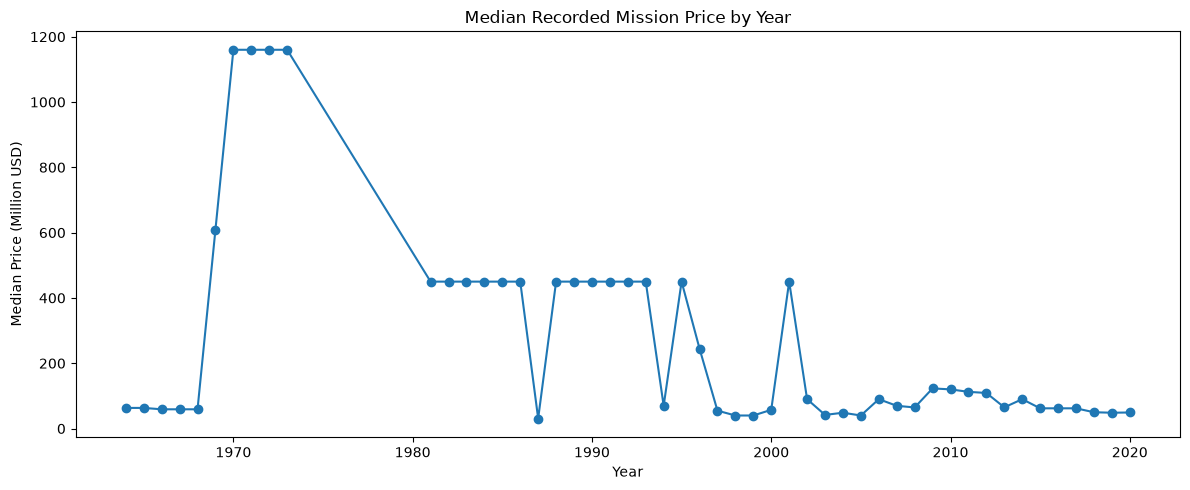

In [58]:
plt.figure(figsize=(12, 5))
plt.plot(
    price_year.index,
    price_year["median"],
    marker="o"
)
plt.title("Median Recorded Mission Price by Year")
plt.xlabel("Year")
plt.ylabel("Median Price (Million USD)")
plt.tight_layout()
plt.show()

In [59]:
org_price = (
    data[data["Price_Million_USD"].notna()]
    .groupby("Organisation")
    .agg(
        Missions=("Price_Million_USD", "count"),
        Median_Price=("Price_Million_USD", "median")
    )
)
org_price_20 = org_price[
    org_price["Missions"] >= 20
].sort_values(
    "Median_Price",
    ascending=False
)
display(org_price_20)

,Missions,Median_Price
Organisation,,
NASA,149,450.0
Arianespace,96,200.0
ULA,98,123.0
MHI,37,90.0
US Air Force,26,59.0
SpaceX,99,56.5
Roscosmos,23,48.5
VKS RF,33,41.8
Northrop,83,40.0


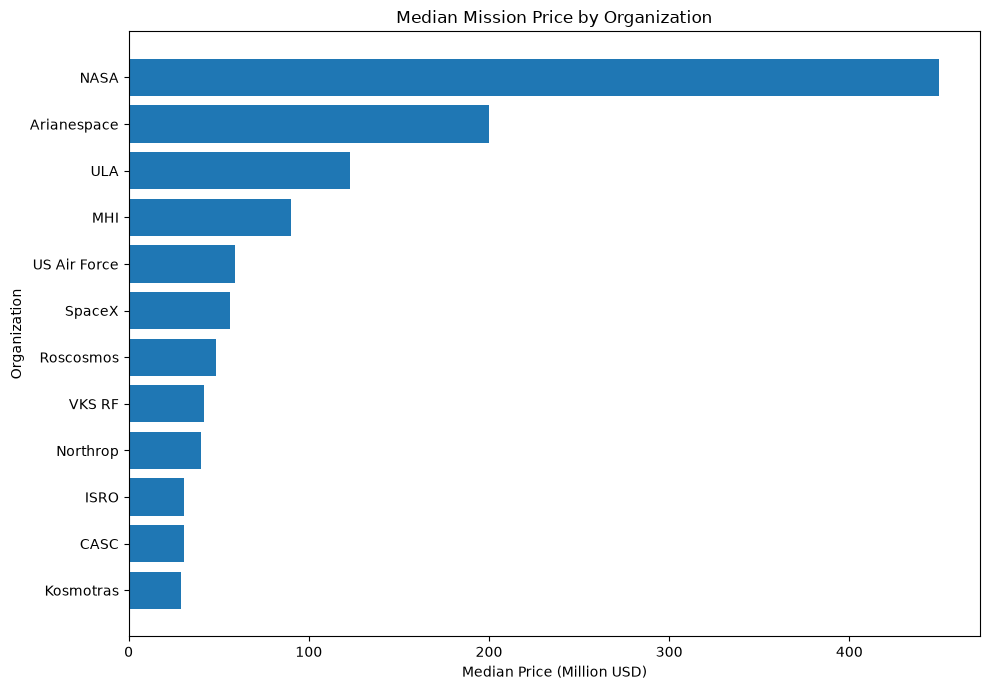

In [60]:
org_price_plot = org_price_20.head(15).sort_values(
    "Median_Price"
)
plt.figure(figsize=(10, 7))
plt.barh(
    org_price_plot.index,
    org_price_plot["Median_Price"]
)
plt.title("Median Mission Price by Organization")
plt.xlabel("Median Price (Million USD)")
plt.ylabel("Organization")
plt.tight_layout()
plt.show()

In [61]:
print("Unique Organizations:", data["Organisation"].nunique())
print("Unique Countries:", data["Country"].nunique())
print("Unique Rocket Names:", data["Rocket_Name"].nunique())
print("Unique Years:", data["Year"].nunique())
print("Unique Months:", data["Month"].nunique())

Unique Organizations: 56
Unique Countries: 22
Unique Rocket Names: 352
Unique Years: 64
Unique Months: 12


In [62]:
print("\nRocket frequency:")
display(data["Rocket_Name"].value_counts().head(20))


Rocket frequency:


Rocket_Name
Cosmos-3M (11K65M)         446
Voskhod                    299
Molniya-M /Block ML        128
Cosmos-2I (63SM)           126
Soyuz U                    125
Tsyklon-3                  122
Tsyklon-2                  106
Vostok-2M                   93
Molniya-M /Block 2BL        87
Ariane 5 ECA                75
Delta II 7925               62
Atlas-SLV3 Agena-D          47
Vostok-2                    45
Molniya-M /Block L          44
Ariane 44L                  41
Molniya                     40
Space Shuttle Discovery     39
Long March 2C               38
Cosmos-2I (63S1)            38
Thor DM-21 Agena-B          38
Name: count, dtype: int64[pyarrow]

In [63]:
print("\nPrice availability by organization:")
price_availability = (
    data.groupby("Organisation")["Price_Million_USD"]
    .agg(
        Total_Missions="size",
        Known_Prices="count"
    )
)
price_availability["Price_Availability_%"] = (
    price_availability["Known_Prices"] /
    price_availability["Total_Missions"] * 100
)
display(
    price_availability
    .sort_values("Known_Prices", ascending=False)
    .head(20)
)


Price availability by organization:


,Total_Missions,Known_Prices,Price_Availability_%
Organisation,,,
CASC,250,157,62.8
NASA,203,149,73.399015
SpaceX,100,99,99.0
ULA,140,98,70.0
Arianespace,279,96,34.408602
Northrop,83,83,100.0
ISRO,76,67,88.157895
MHI,84,37,44.047619
VKS RF,201,33,16.41791


**ML Model:**
 Price had 3,360 missing entries (77.71%) - too many to drop without biasing results. We preserved the full dataset by imputing missing prices using two complementary approaches: an Extra Trees regression model trained on Organisation, Country, Year, and Month; and a Global Median fallback when model predictions were unreliable due to limited historical data for specific organisations. 

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor

In [65]:
known_data = data[data["Price_Million_USD"].notna()].copy()
missing_data = data[data["Price_Million_USD"].isna()].copy()

print("Known price rows:", len(known_data))
print("Missing price rows:", len(missing_data))

Known price rows: 963
Missing price rows: 3360


In [66]:
features = [
    "Organisation",
    "Country",
    "Year",
    "Month"
]
target = "Price_Million_USD"
X = known_data[features]
y = known_data[target]
X_missing = missing_data[features]

In [67]:
categorical_features = [
    "Organisation",
    "Country",
    "Month"
]
numeric_features = [
    "Year"
]

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [69]:
extra_trees_model = ExtraTreesRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [70]:
extra_trees_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", extra_trees_model)
    ]
)

In [71]:
extra_trees_final.fit(X, y)
print("Extra Trees model trained successfully!")

Extra Trees model trained successfully!


In [72]:
predicted_prices = extra_trees_final.predict(X_missing)
# Prevent negative predictions
predicted_prices = np.maximum(predicted_prices, 0)
final_predictions = missing_data.copy()
final_predictions["Estimated_Price_M"] = predicted_prices
final_predictions["Prediction_Method"] = "Extra Trees"

In [73]:
known_price_count = (
    known_data
    .groupby("Organisation")
    .size()
)
final_predictions["Known_Price_Count"] = (
    final_predictions["Organisation"]
    .map(known_price_count)
    .fillna(0)
    .astype(int)
)

In [74]:
def reliability_category(count):
    if count < 5:
        return "Low"

    elif count <= 20:
        return "Moderate"

    else:
        return "Higher"
final_predictions["Prediction_Reliability"] = (
    final_predictions["Known_Price_Count"]
    .apply(reliability_category)
)

In [75]:
global_median = known_data["Price_Million_USD"].median()
rvsn_mask = (
    final_predictions["Organisation"] == "RVSN USSR"
)
final_predictions.loc[
    rvsn_mask,
    "Estimated_Price_M"
] = global_median
final_predictions.loc[
    rvsn_mask,
    "Prediction_Method"
] = "Global Median Fallback"

In [76]:
print("\nPrediction Summary:")
print(
    final_predictions["Estimated_Price_M"].describe()
)
print("\nPrediction Methods:")
print(
    final_predictions["Prediction_Method"].value_counts()
)
print("\nPrediction Reliability:")
print(
    final_predictions["Prediction_Reliability"].value_counts()
)


Prediction Summary:
count    3360.000000
mean       88.839951
std       141.922822
min        14.095778
25%        62.000000
50%        62.000000
75%        62.000000
max      1160.000000
Name: Estimated_Price_M, dtype: float64

Prediction Methods:
Prediction_Method
Global Median Fallback    1775
Extra Trees               1585
Name: count, dtype: int64

Prediction Reliability:
Prediction_Reliability
Low         2258
Higher       764
Moderate     338
Name: count, dtype: int64


In [77]:
final_data = data.copy()
# Identify originally missing prices
final_data["Price_Was_Missing"] = (
    final_data["Price_Million_USD"].isna()
)
# Create prediction column
final_data["Estimated_Price_M"] = np.nan
# Default values for observed prices
final_data["Prediction_Method"] = "Observed"
final_data["Prediction_Reliability"] = "Observed"
# Add predictions using the original row index
final_data.loc[
    final_predictions.index,
    "Estimated_Price_M"
] = final_predictions["Estimated_Price_M"]
final_data.loc[
    final_predictions.index,
    "Prediction_Method"
] = final_predictions["Prediction_Method"]
final_data.loc[
    final_predictions.index,
    "Prediction_Reliability"
] = final_predictions["Prediction_Reliability"]

In [78]:
final_data["Price_Completed_M"] = (
    final_data["Price_Million_USD"]
)
missing_mask = (
    final_data["Price_Completed_M"].isna()
)
final_data.loc[
    missing_mask,
    "Price_Completed_M"
] = final_data.loc[
    missing_mask,
    "Estimated_Price_M"
]

In [79]:
print("\nFinal Dataset Verification")
print("Original rows:", len(data))
print("Final rows:", len(final_data))
print("Original missing prices:", data["Price_Million_USD"].isna().sum())
print("Final missing completed prices:", final_data["Price_Completed_M"].isna().sum())
print("Estimated prices:", final_data["Estimated_Price_M"].notna().sum())


Final Dataset Verification
Original rows: 4323
Final rows: 4323
Original missing prices: 3360
Final missing completed prices: 0
Estimated prices: 3360


In [82]:
observed_mask = (
    data["Price_Million_USD"].notna()
)
prices_unchanged = np.allclose(
    data.loc[observed_mask, "Price_Million_USD"],
    final_data.loc[observed_mask, "Price_Million_USD"]
)
print("Known prices preserved:", prices_unchanged)

Known prices preserved: True


In [83]:
final_data["Price_Completed_M"]=final_data["Price_Completed_M"].round(2)
final_data[
    [
        "Organisation",
        "Country",
        "Rocket_Name",
        "Year",
        "Month",
        "Price_Million_USD",
        "Estimated_Price_M",
        "Price_Completed_M",
        "Prediction_Method",
        "Prediction_Reliability"
    ]
].head(20)

,Organisation,Country,Rocket_Name,Year,Month,Price_Million_USD,Estimated_Price_M,Price_Completed_M,Prediction_Method,Prediction_Reliability
0,SpaceX,USA,Falcon 9 Block 5,2020,August,50.0,NaN,50.0,Observed,Observed
1,CASC,China,Long March 2D,2020,August,29.75,NaN,29.75,Observed,Observed
2,SpaceX,USA,Starship Prototype,2020,August,<NA>,49.999792,50.0,Extra Trees,Higher
3,Roscosmos,Kazakhstan,Proton-M/Briz-M,2020,July,65.0,NaN,65.0,Observed,Observed
4,ULA,USA,Atlas V 541,2020,July,145.0,NaN,145.0,Observed,Observed
5,CASC,China,Long March 4B,2020,July,64.68,NaN,64.68,Observed,Observed
6,Roscosmos,Kazakhstan,Soyuz 2.1a,2020,July,48.5,NaN,48.5,Observed,Observed
7,CASC,China,Long March 5,2020,July,<NA>,42.479289,42.48,Extra Trees,Higher
8,SpaceX,USA,Falcon 9 Block 5,2020,July,50.0,NaN,50.0,Observed,Observed
9,JAXA,Japan,H-IIA 202,2020,July,90.0,NaN,90.0,Observed,Observed


In [84]:
final_data.to_csv(
    "space_mission_final_predictions.csv",
    index=False
)
print("\nFinal dataset saved successfully!")


Final dataset saved successfully!


In [85]:
final_data.info()

<class 'pandas.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   Organisation            4323 non-null   string             
 1   Location                4323 non-null   string             
 2   Date                    4323 non-null   datetime64[us, UTC]
 3   Detail                  4323 non-null   string             
 4   Rocket_Status           4323 non-null   string             
 5   Price_Million_USD       963 non-null    Float64            
 6   Mission_Status          4323 non-null   string             
 7   Year                    4323 non-null   int32              
 8   Month                   4323 non-null   string             
 9   Decade                  4323 non-null   Int64              
 10  Rocket_Name             4323 non-null   string             
 11  Country                 4323 non-null   string             

**Key Insights After Fixing Dataset**
1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate analysis

**1. Univariate Analysis:**
 Analyzes one variable at a time to understand its distribution, frequency, or characteristics.

In [87]:
eda_data = final_data.copy()
print("Rows:", eda_data.shape[0])
print("Columns:", eda_data.shape[1])

Rows: 4323
Columns: 17


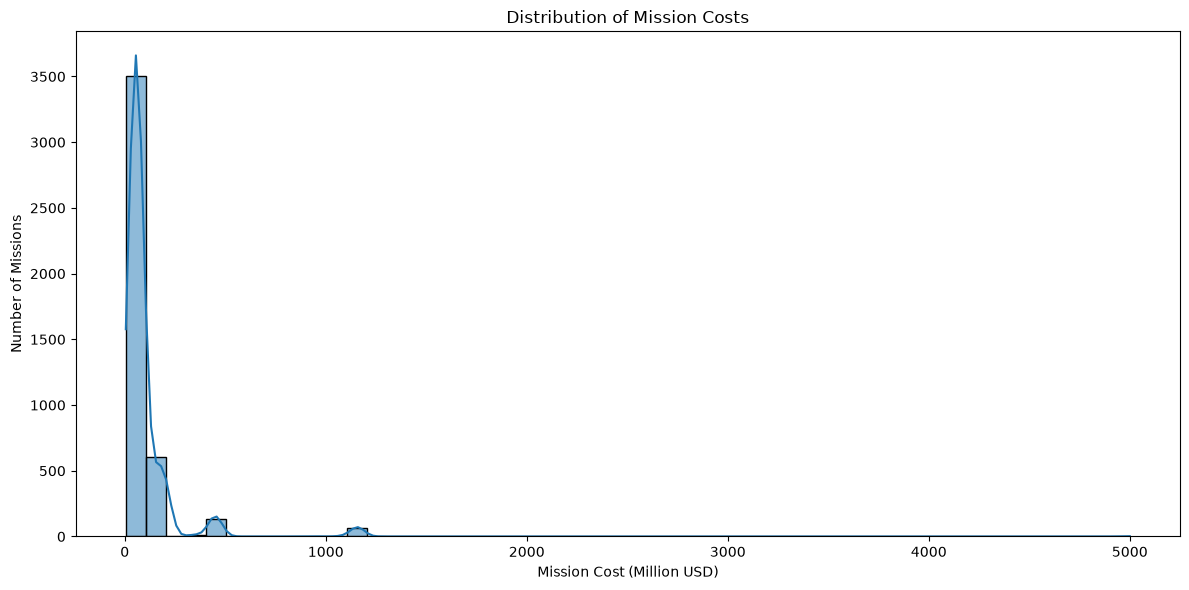

In [88]:
plt.figure(figsize=(12, 6))
sns.histplot(
    eda_data["Price_Completed_M"],
    bins=50,
    kde=True
)
plt.title("Distribution of Mission Costs")
plt.xlabel("Mission Cost (Million USD)")
plt.ylabel("Number of Missions")
plt.tight_layout()
plt.show()

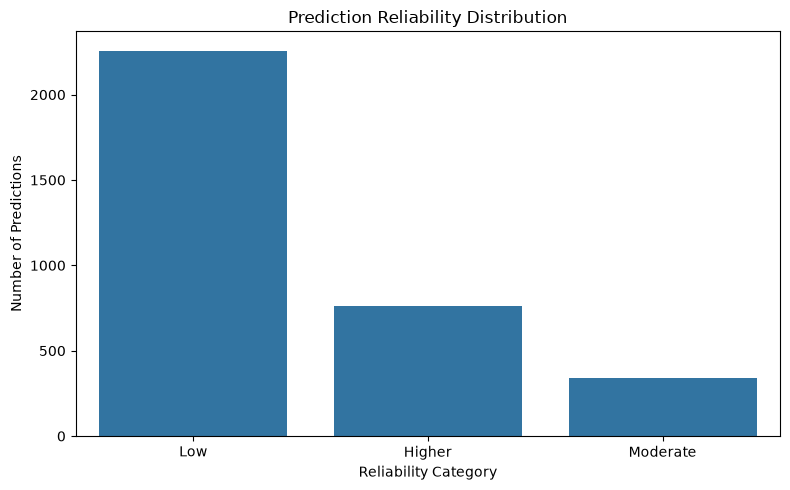

In [89]:
reliability_counts = (
    final_predictions["Prediction_Reliability"]
    .value_counts()
)
plt.figure(figsize=(8, 5))
sns.barplot(
    x=reliability_counts.index,
    y=reliability_counts.values
)
plt.title("Prediction Reliability Distribution")
plt.xlabel("Reliability Category")
plt.ylabel("Number of Predictions")
plt.tight_layout()
plt.show()

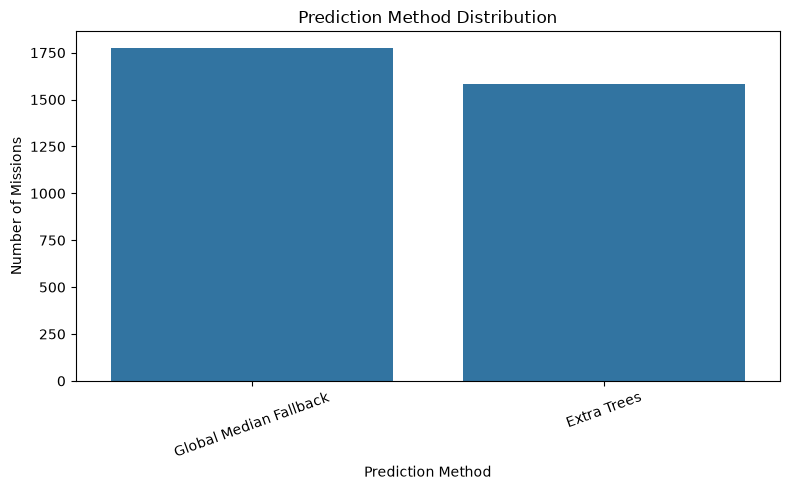

In [90]:
method_counts = (
    final_predictions["Prediction_Method"]
    .value_counts()
)
plt.figure(figsize=(8, 5))
sns.barplot(
    x=method_counts.index,
    y=method_counts.values
)
plt.title("Prediction Method Distribution")
plt.xlabel("Prediction Method")
plt.ylabel("Number of Missions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

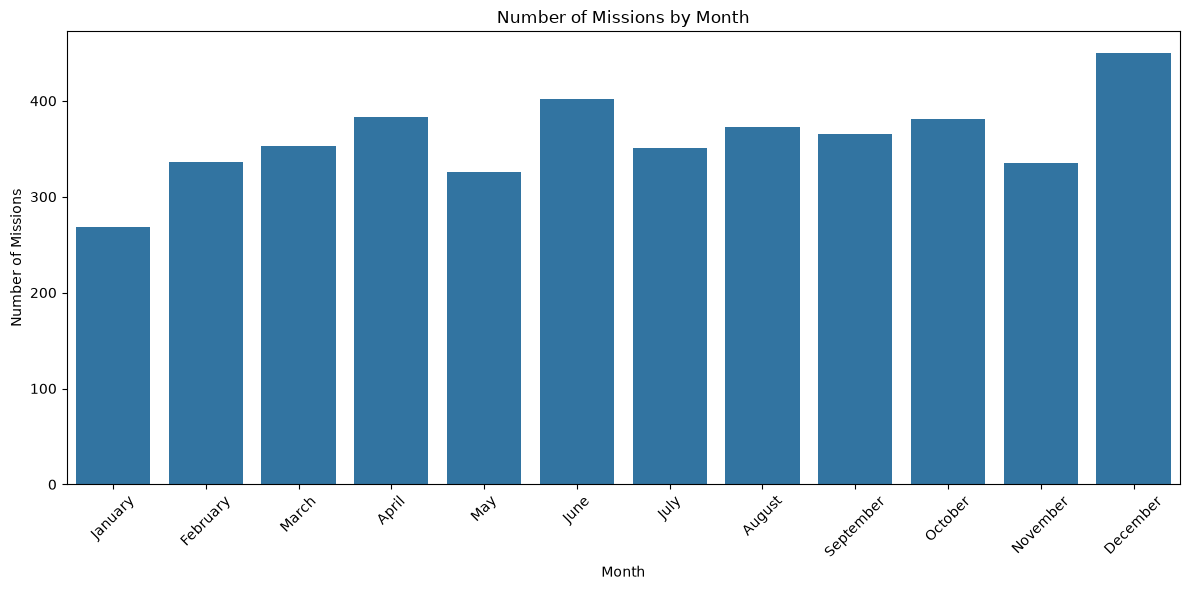

In [92]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]
monthly_missions = (
    eda_data["Month"]
    .value_counts()
    .reindex(month_order)
)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=monthly_missions.index,
    y=monthly_missions.values
)
plt.title("Number of Missions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Missions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

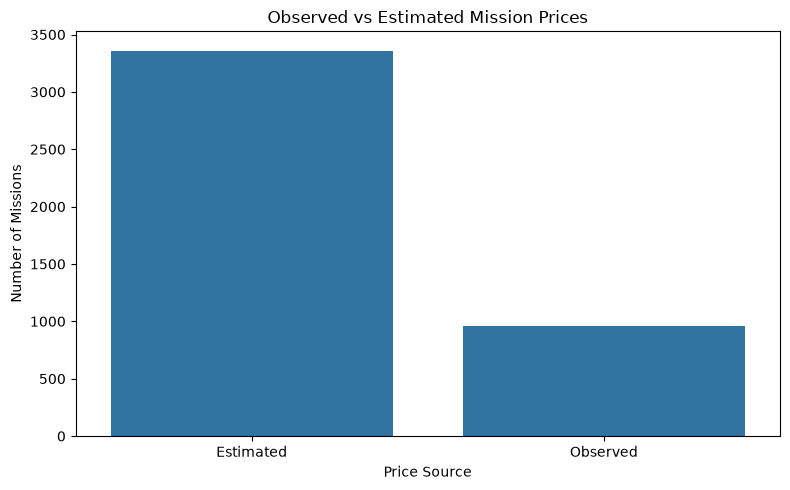

In [93]:
price_source = (
    eda_data["Price_Was_Missing"]
    .map({
        False: "Observed",
        True: "Estimated"
    })
)
source_counts = price_source.value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(
    x=source_counts.index,
    y=source_counts.values
)
plt.title("Observed vs Estimated Mission Prices")
plt.xlabel("Price Source")
plt.ylabel("Number of Missions")
plt.tight_layout()
plt.show()

**2. Bivariate Analysis:**
Analyzes two variables to identify relationships, comparisons, or trends between them.

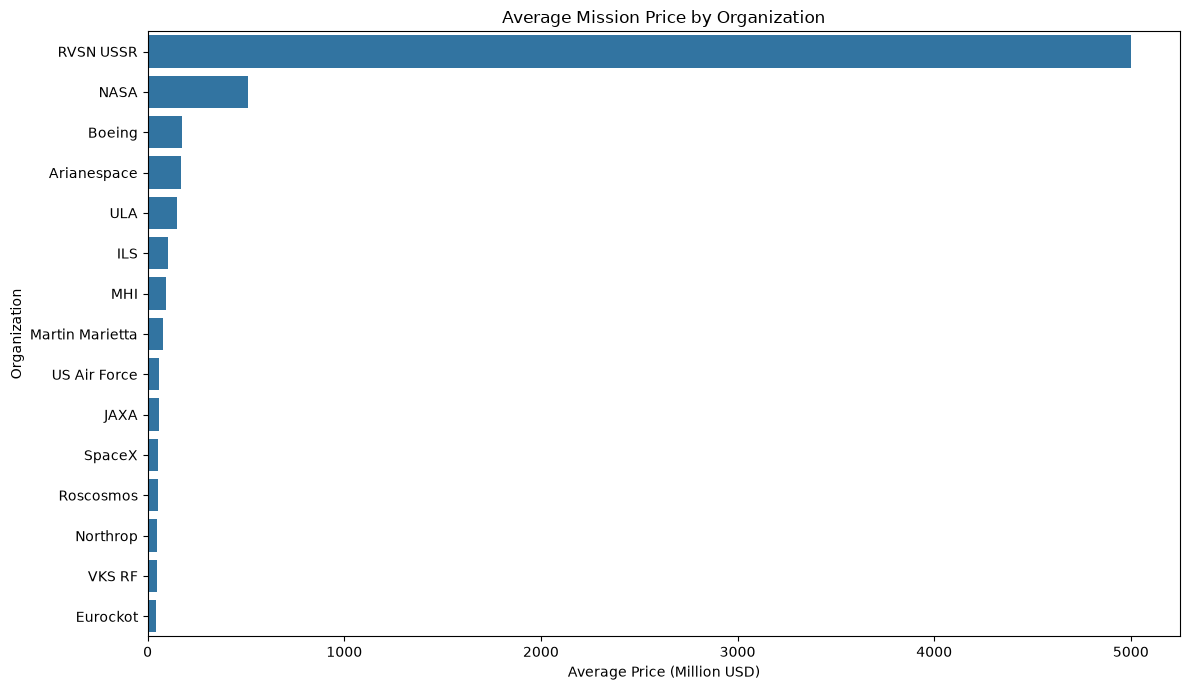

In [94]:
org_price = (
    known_data
    .groupby("Organisation")["Price_Million_USD"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 7))
sns.barplot(
    x=org_price["mean"],
    y=org_price.index
)
plt.title("Average Mission Price by Organization")
plt.xlabel("Average Price (Million USD)")
plt.ylabel("Organization")
plt.tight_layout()
plt.show()

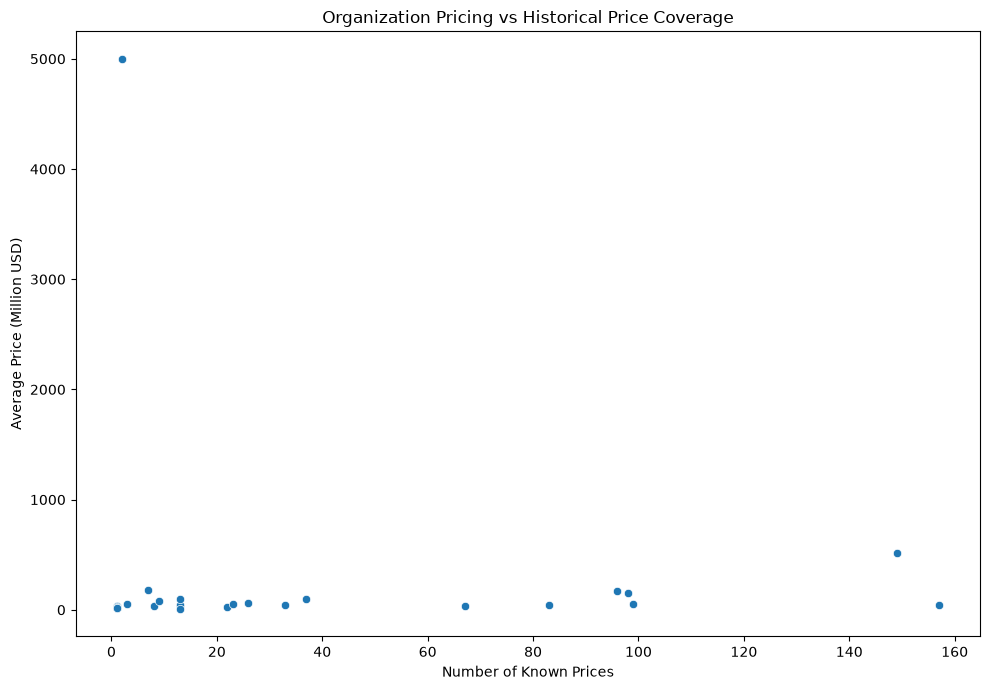

In [95]:
org_stats = (
    known_data
    .groupby("Organisation")["Price_Million_USD"]
    .agg(
        Average_Price="mean",
        Known_Prices="count"
    )
    .reset_index()
)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=org_stats,
    x="Known_Prices",
    y="Average_Price"
)
plt.title("Organization Pricing vs Historical Price Coverage")
plt.xlabel("Number of Known Prices")
plt.ylabel("Average Price (Million USD)")
plt.tight_layout()
plt.show()

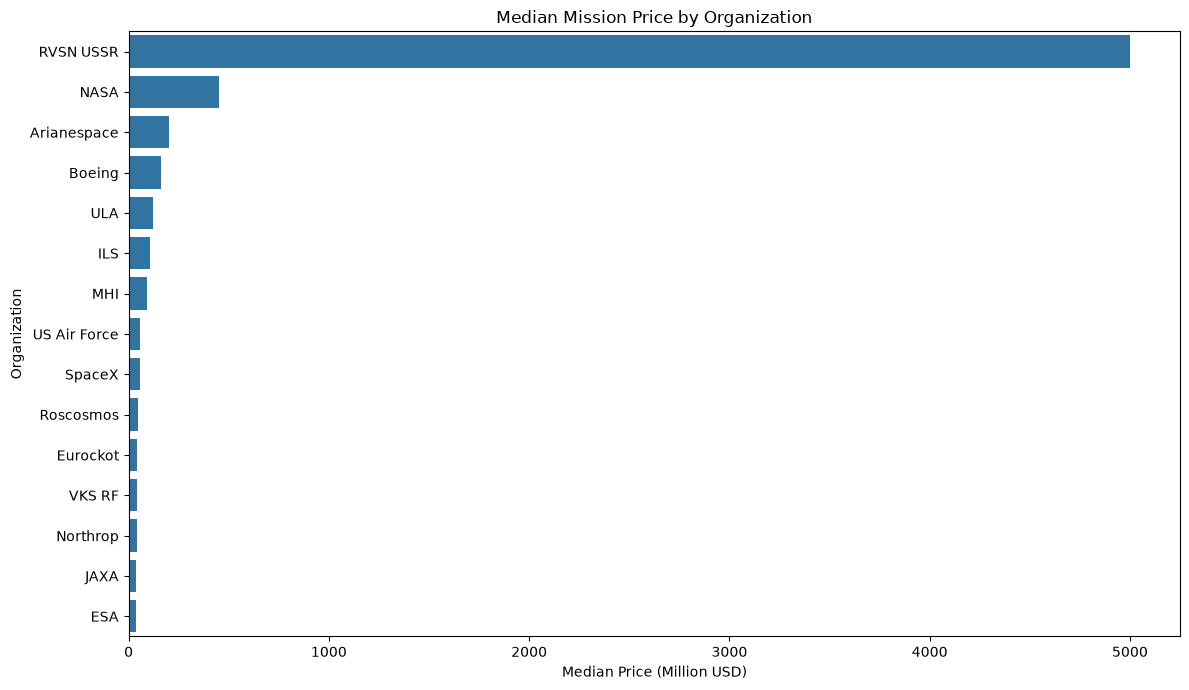

In [96]:
org_median = (
    known_data
    .groupby("Organisation")["Price_Million_USD"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 7))
sns.barplot(
    x=org_median.values,
    y=org_median.index
)
plt.title("Median Mission Price by Organization")
plt.xlabel("Median Price (Million USD)")
plt.ylabel("Organization")
plt.tight_layout()
plt.show()

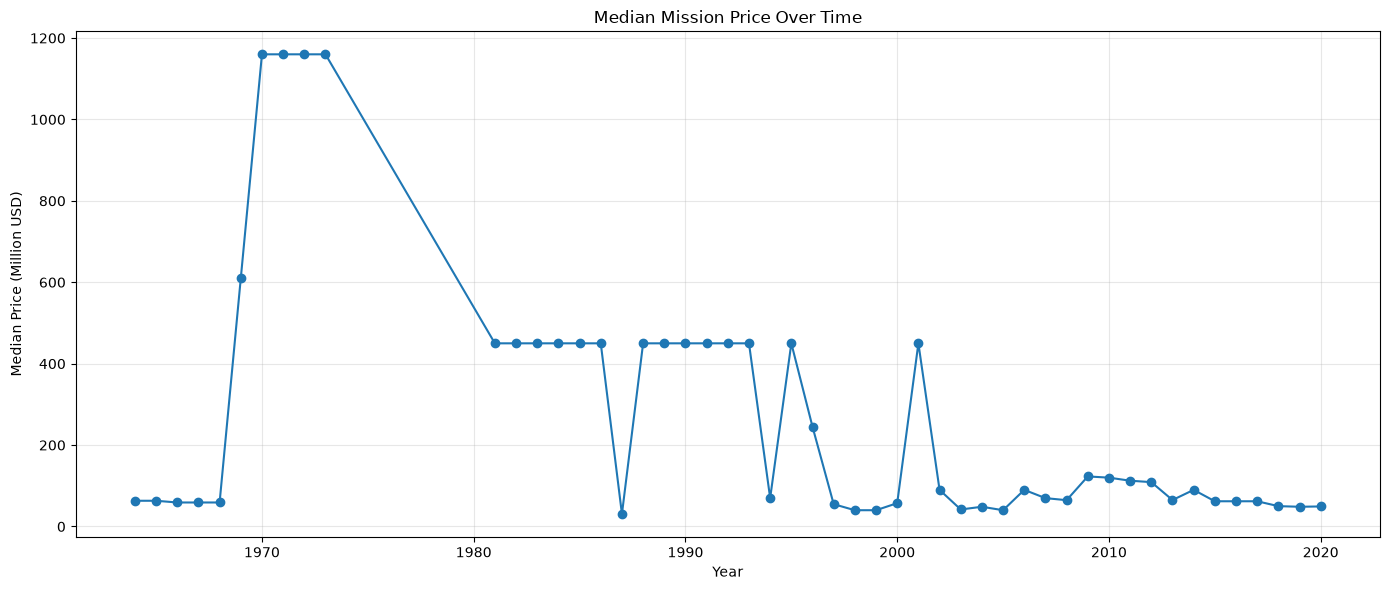

In [97]:
year_price = (
    known_data
    .groupby("Year")["Price_Million_USD"]
    .median()
)
plt.figure(figsize=(14, 6))
plt.plot(
    year_price.index,
    year_price.values,
    marker="o"
)
plt.title("Median Mission Price Over Time")
plt.xlabel("Year")
plt.ylabel("Median Price (Million USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

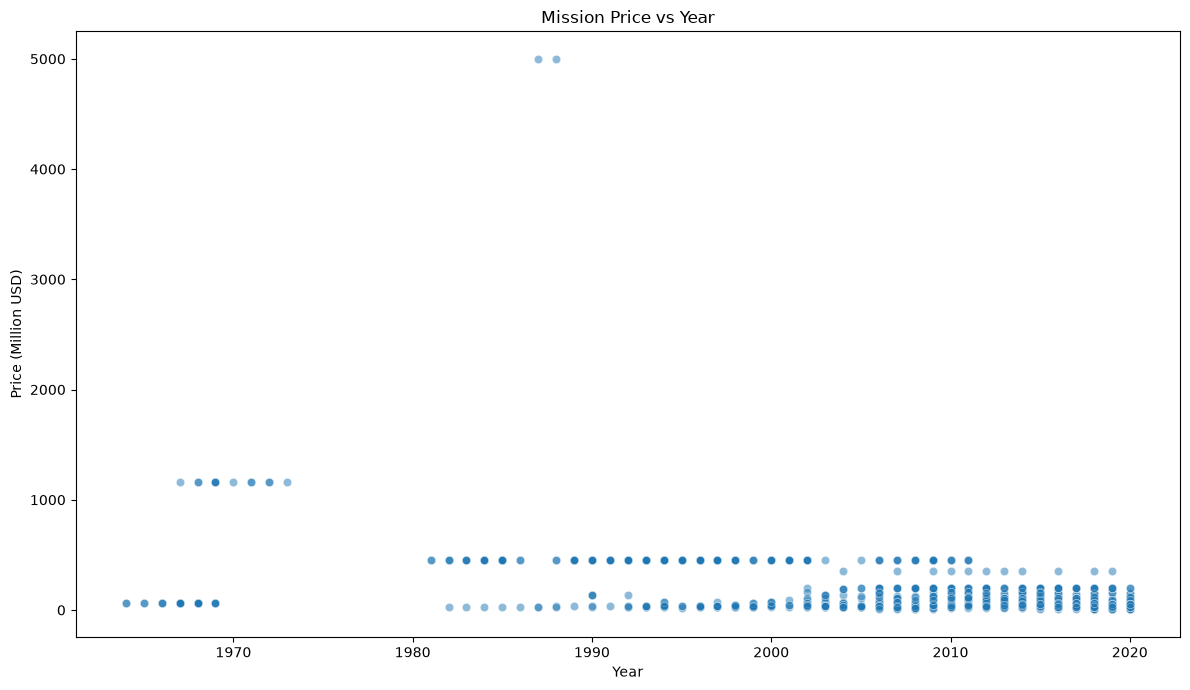

In [98]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=known_data,
    x="Year",
    y="Price_Million_USD",
    alpha=0.5
)
plt.title("Mission Price vs Year")
plt.xlabel("Year")
plt.ylabel("Price (Million USD)")
plt.tight_layout()
plt.show()

In [99]:
top_expensive = (
    known_data[
        [
            "Organisation",
            "Country",
            "Rocket_Name",
            "Year",
            "Price_Million_USD"
        ]
    ]
    .sort_values(
        "Price_Million_USD",
        ascending=False
    )
    .head(15)
)
top_expensive

,Organisation,Country,Rocket_Name,Year,Price_Million_USD
1916,RVSN USSR,Kazakhstan,Energiya/Buran,1988,5000.0
2000,RVSN USSR,Kazakhstan,Energiya/Polyus,1987,5000.0
3683,NASA,USA,Saturn V,1968,1160.0
3603,NASA,USA,Saturn V,1968,1160.0
3716,NASA,USA,Saturn V,1967,1160.0
3149,NASA,USA,Saturn V,1973,1160.0
3243,NASA,USA,Saturn V,1972,1160.0
3475,NASA,USA,Saturn V,1970,1160.0
3384,NASA,USA,Saturn V,1971,1160.0
3328,NASA,USA,Saturn V,1971,1160.0


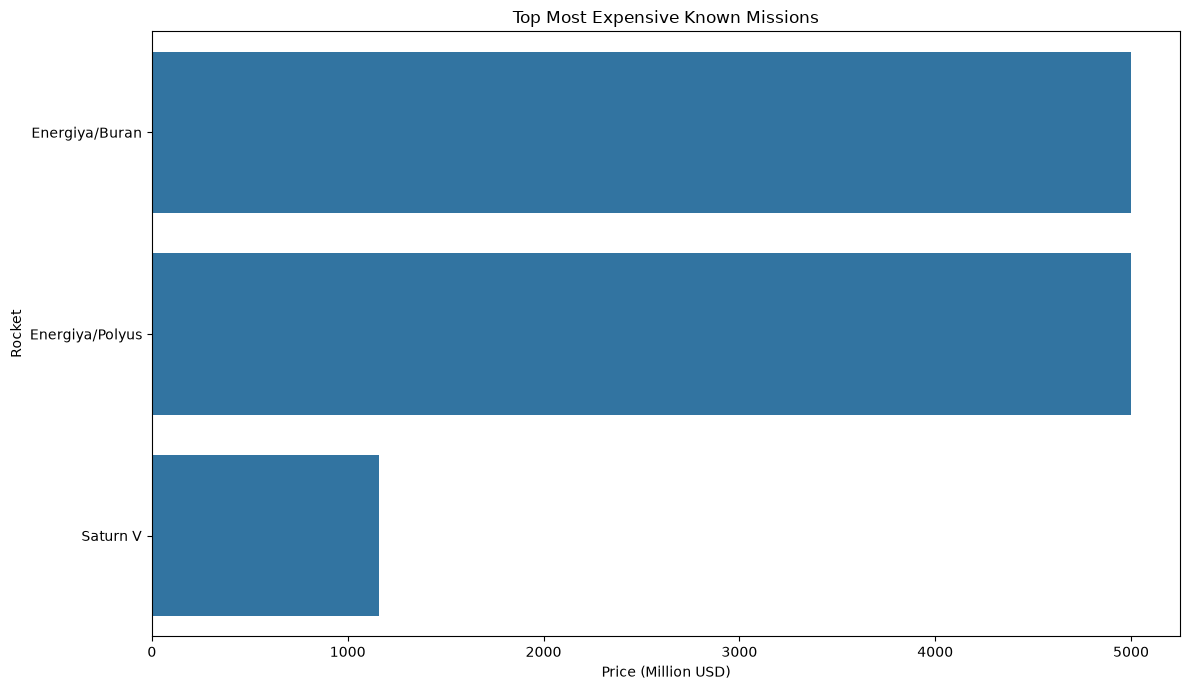

In [100]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_expensive,
    x="Price_Million_USD",
    y="Rocket_Name"
)
plt.title("Top Most Expensive Known Missions")
plt.xlabel("Price (Million USD)")
plt.ylabel("Rocket")
plt.tight_layout()
plt.show()

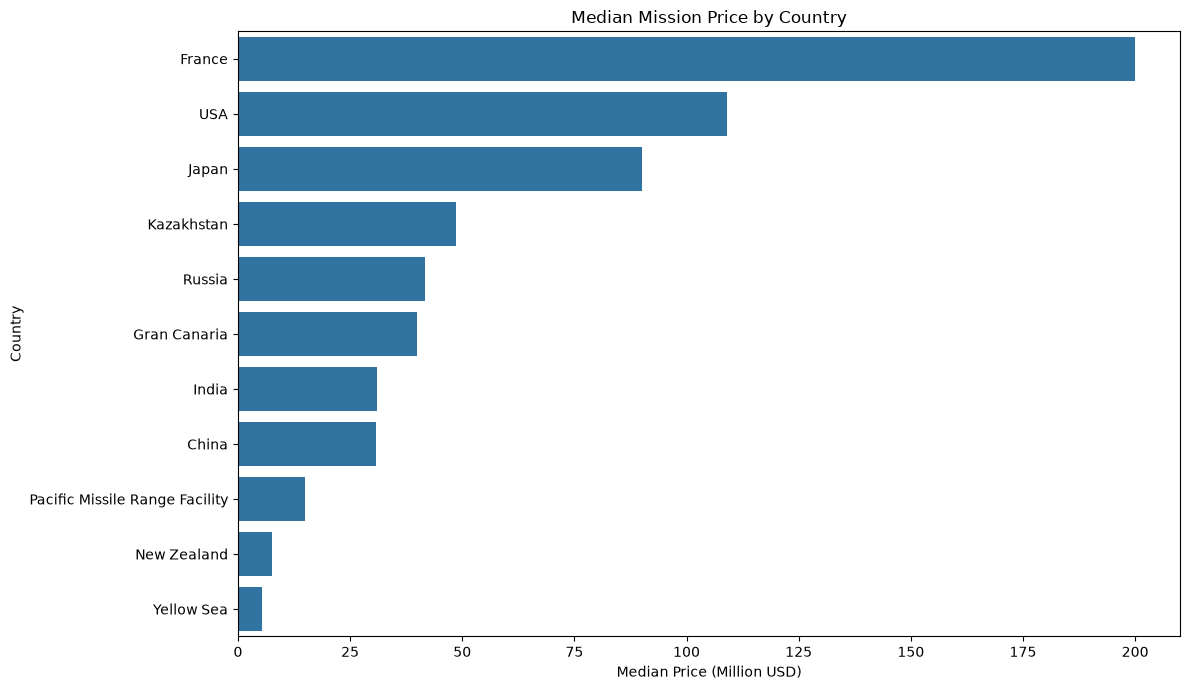

In [101]:
country_price = (
    known_data
    .groupby("Country")["Price_Million_USD"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 7))
sns.barplot(
    x=country_price.values,
    y=country_price.index
)
plt.title("Median Mission Price by Country")
plt.xlabel("Median Price (Million USD)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

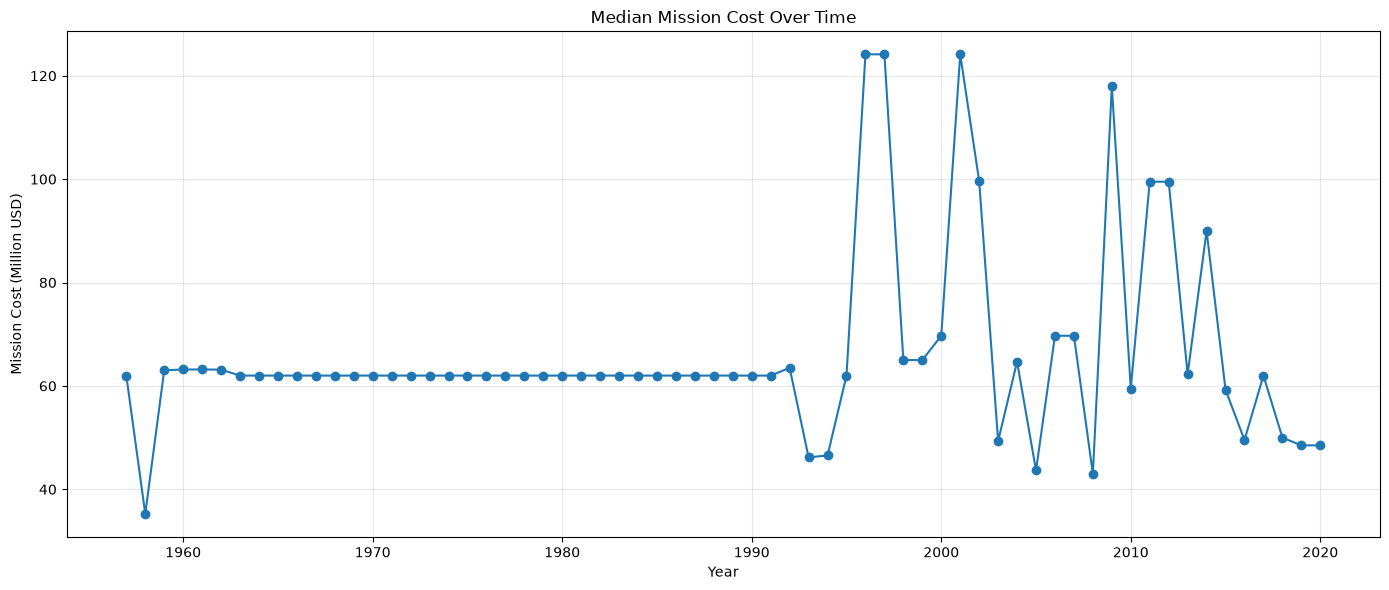

In [102]:
yearly_price = (
    eda_data
    .groupby("Year")["Price_Completed_M"]
    .median()
)
plt.figure(figsize=(14, 6))
plt.plot(
    yearly_price.index,
    yearly_price.values,
    marker="o"
)
plt.title("Median Mission Cost Over Time")
plt.xlabel("Year")
plt.ylabel("Mission Cost (Million USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

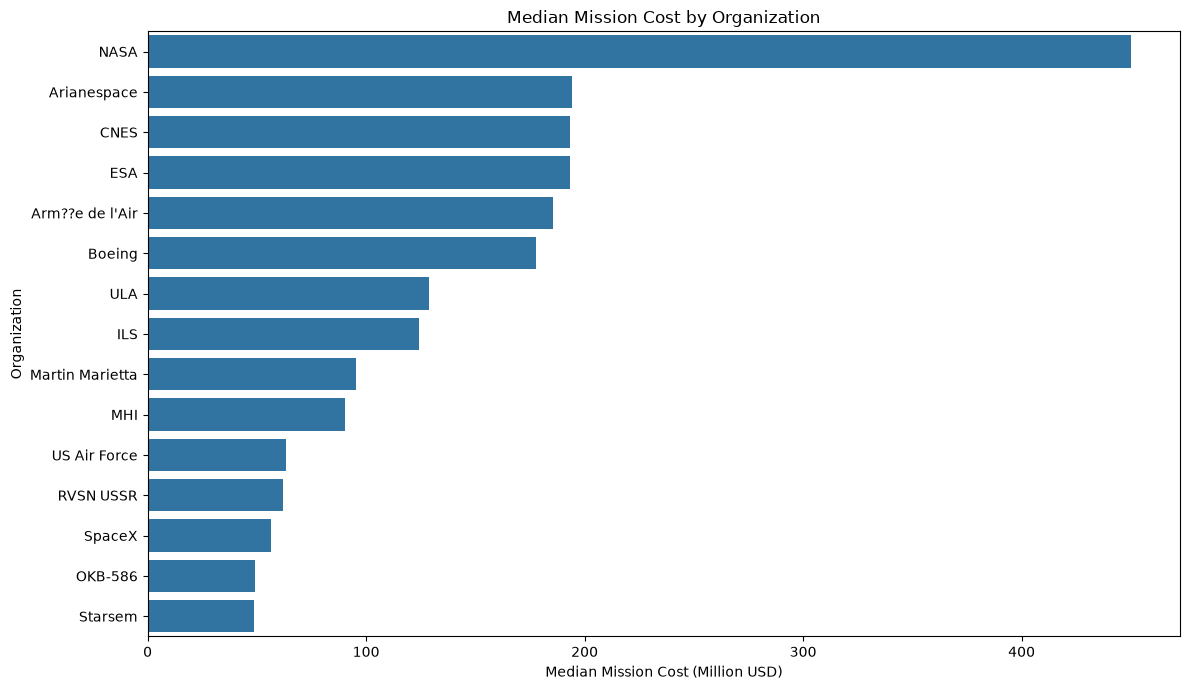

In [103]:
org_price = (
    eda_data
    .groupby("Organisation")["Price_Completed_M"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 7))
sns.barplot(
    x=org_price.values,
    y=org_price.index
)
plt.title("Median Mission Cost by Organization")
plt.xlabel("Median Mission Cost (Million USD)")
plt.ylabel("Organization")
plt.tight_layout()
plt.show()

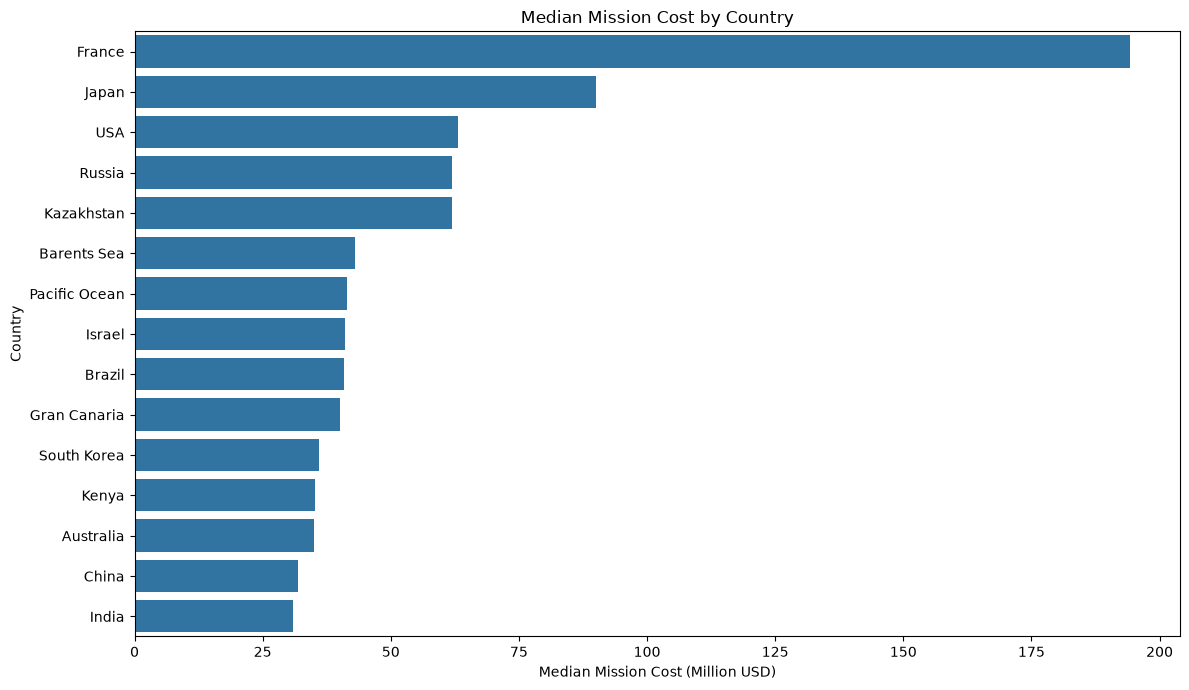

In [104]:
country_price = (
    eda_data
    .groupby("Country")["Price_Completed_M"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(12, 7))
sns.barplot(
    x=country_price.values,
    y=country_price.index
)
plt.title("Median Mission Cost by Country")
plt.xlabel("Median Mission Cost (Million USD)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

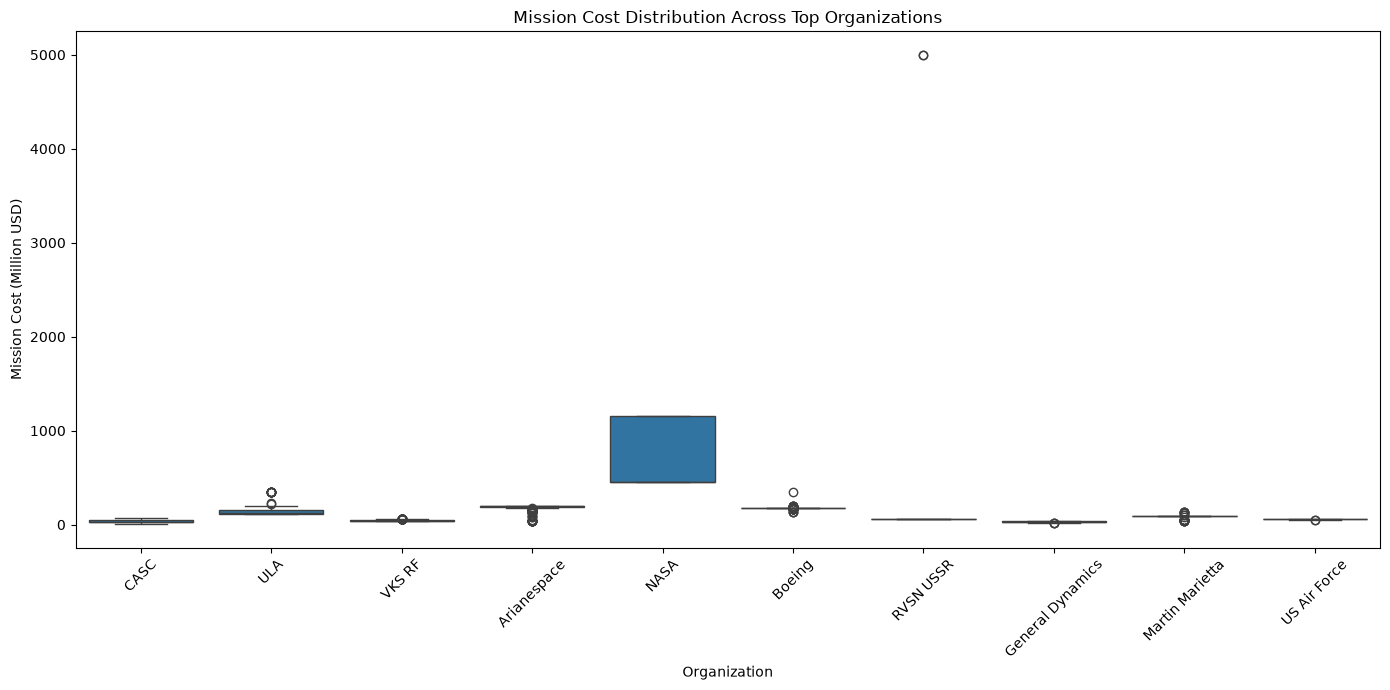

In [105]:
top_orgs = (
    eda_data["Organisation"]
    .value_counts()
    .head(10)
    .index
)
org_box_data = eda_data[
    eda_data["Organisation"].isin(top_orgs)
]
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=org_box_data,
    x="Organisation",
    y="Price_Completed_M"
)
plt.title("Mission Cost Distribution Across Top Organizations")
plt.xlabel("Organization")
plt.ylabel("Mission Cost (Million USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

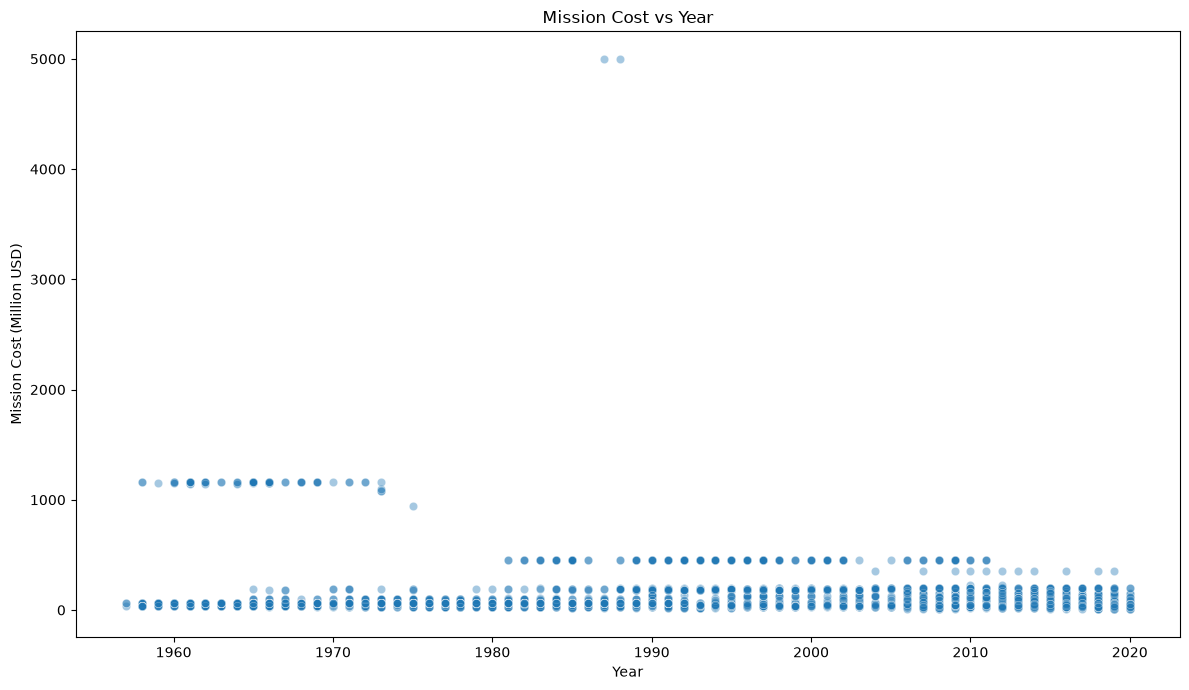

In [106]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=eda_data,
    x="Year",
    y="Price_Completed_M",
    alpha=0.4
)
plt.title("Mission Cost vs Year")
plt.xlabel("Year")
plt.ylabel("Mission Cost (Million USD)")
plt.tight_layout()
plt.show()

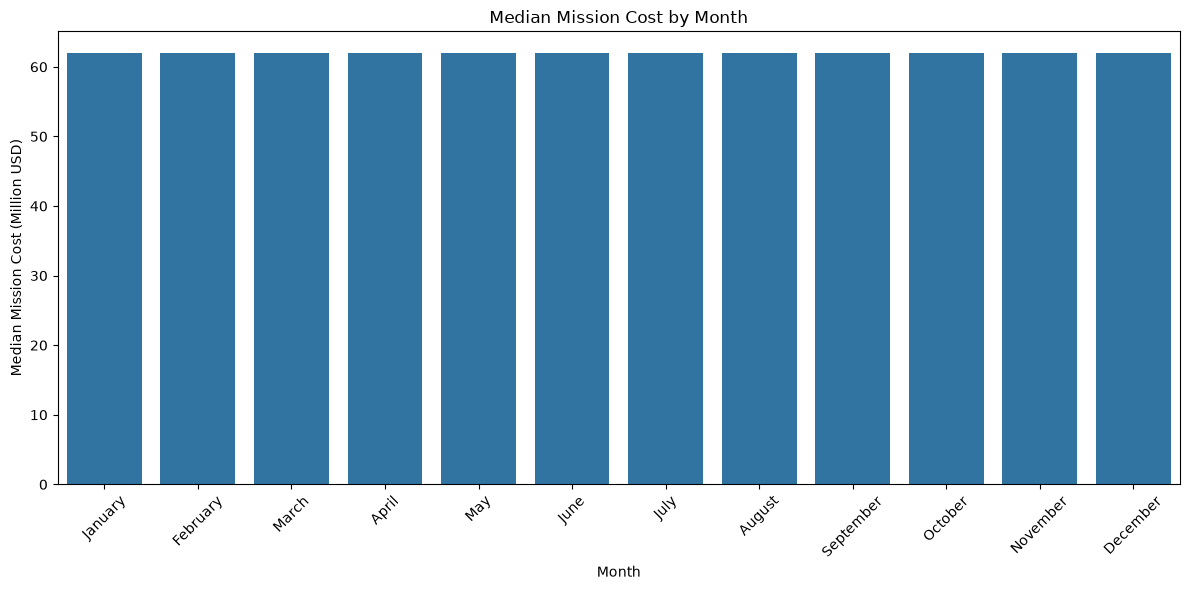

In [107]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]
monthly_price = (
    eda_data
    .groupby("Month")["Price_Completed_M"]
    .median()
    .reindex(month_order)
)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=monthly_price.index,
    y=monthly_price.values
)
plt.title("Median Mission Cost by Month")
plt.xlabel("Month")
plt.ylabel("Median Mission Cost (Million USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

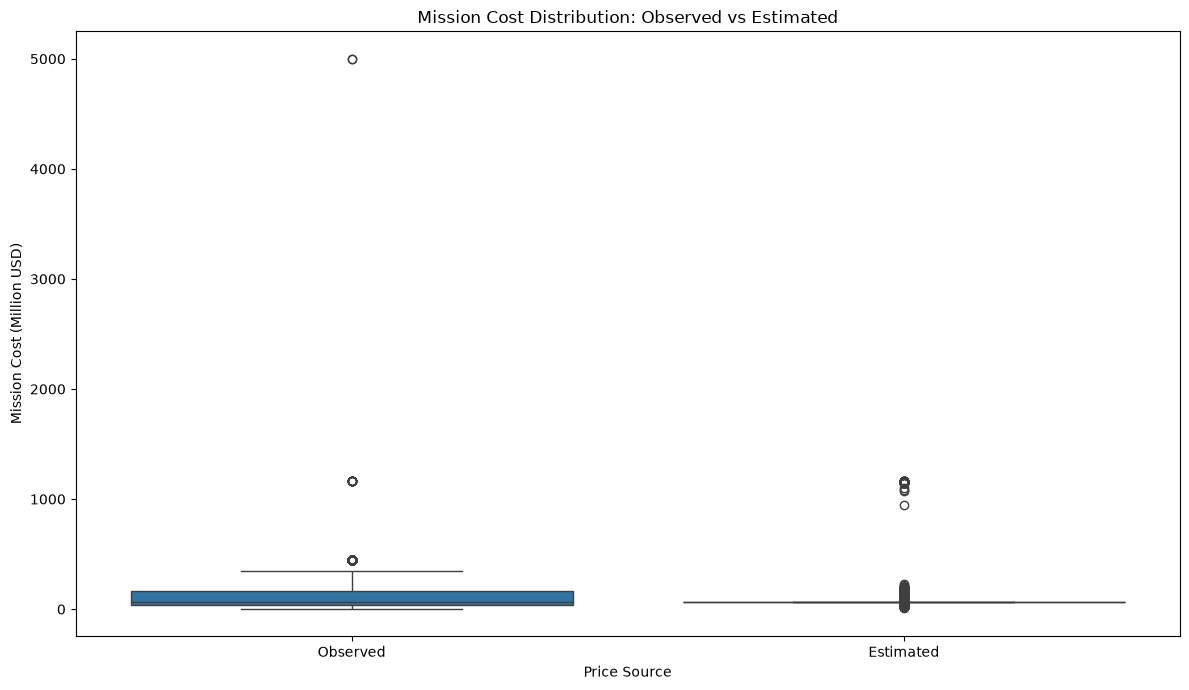

In [108]:
eda_data["Price_Source"] = (
    eda_data["Price_Was_Missing"]
    .map({
        False: "Observed",
        True: "Estimated"
    })
)
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=eda_data,
    x="Price_Source",
    y="Price_Completed_M"
)
plt.title("Mission Cost Distribution: Observed vs Estimated")
plt.xlabel("Price Source")
plt.ylabel("Mission Cost (Million USD)")
plt.tight_layout()
plt.show()

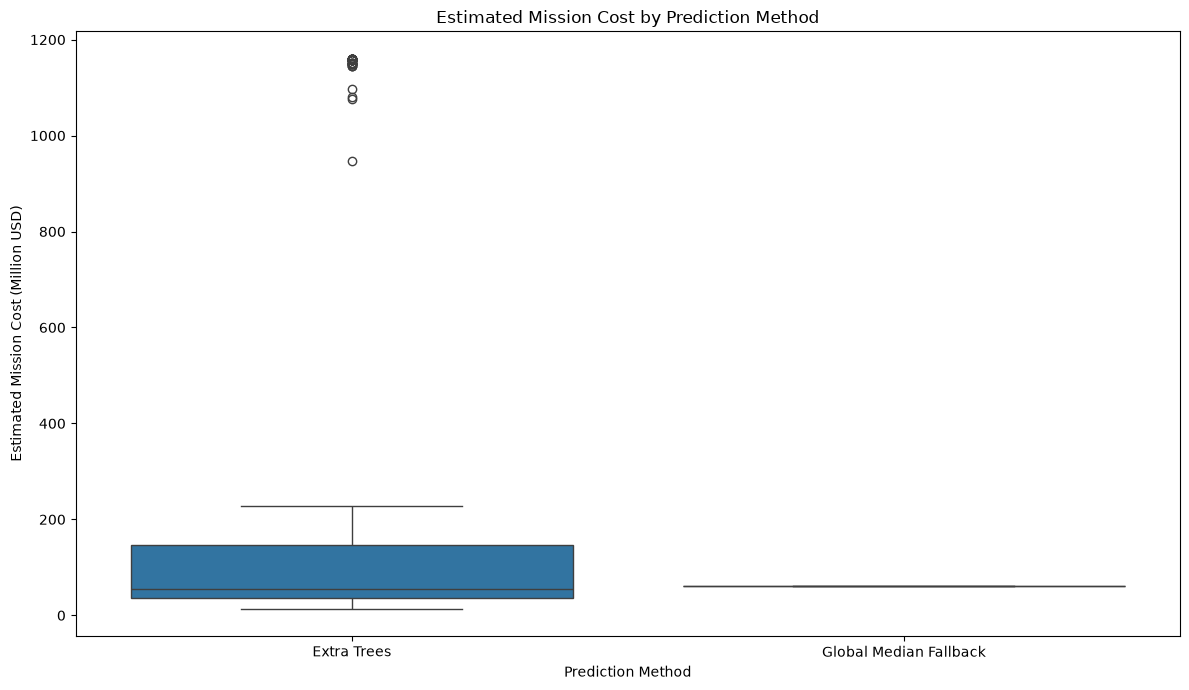

In [109]:
prediction_data = eda_data[
    eda_data["Price_Was_Missing"]
]
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=prediction_data,
    x="Prediction_Method",
    y="Price_Completed_M"
)
plt.title("Estimated Mission Cost by Prediction Method")
plt.xlabel("Prediction Method")
plt.ylabel("Estimated Mission Cost (Million USD)")
plt.tight_layout()
plt.show()

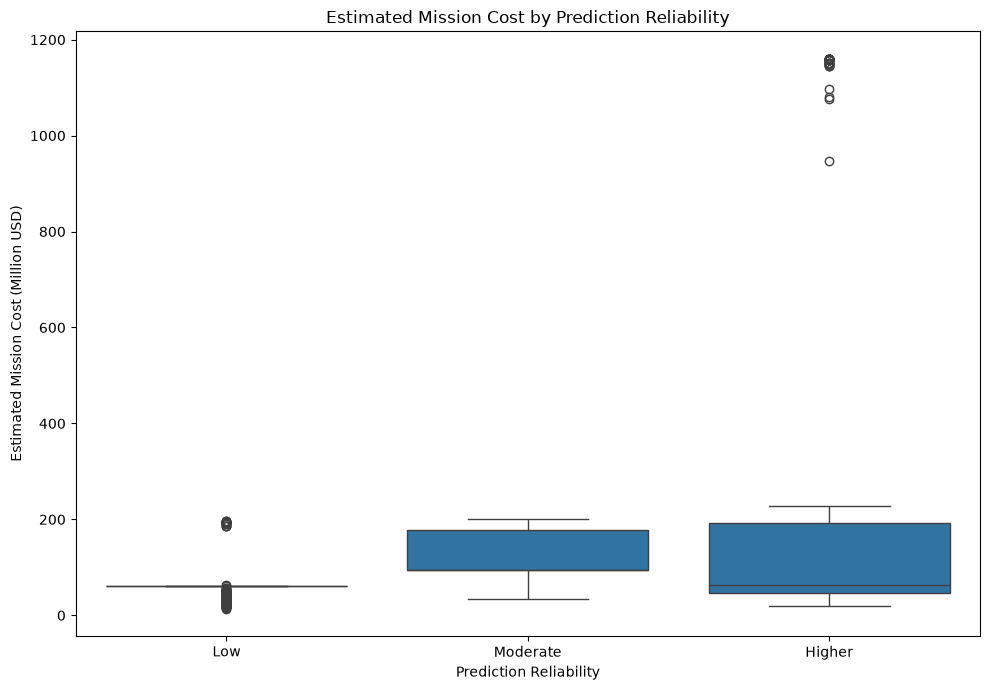

In [110]:
reliability_order = [
    "Low",
    "Moderate",
    "Higher"
]
plt.figure(figsize=(10, 7))
sns.boxplot(
    data=prediction_data,
    x="Prediction_Reliability",
    y="Price_Completed_M",
    order=reliability_order
)
plt.title("Estimated Mission Cost by Prediction Reliability")
plt.xlabel("Prediction Reliability")
plt.ylabel("Estimated Mission Cost (Million USD)")
plt.tight_layout()
plt.show()

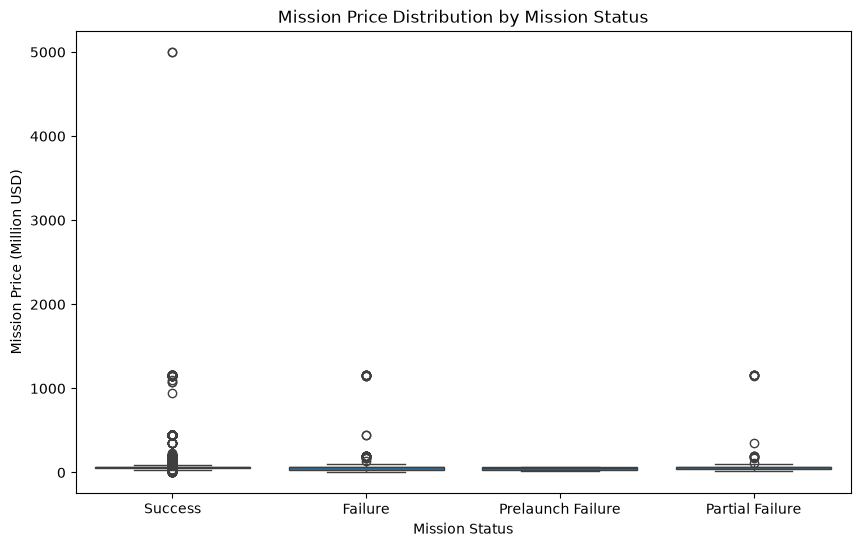

In [111]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=final_data,
    x="Mission_Status",
    y="Price_Completed_M"
)
plt.title("Mission Price Distribution by Mission Status")
plt.xlabel("Mission Status")
plt.ylabel("Mission Price (Million USD)")
plt.show()

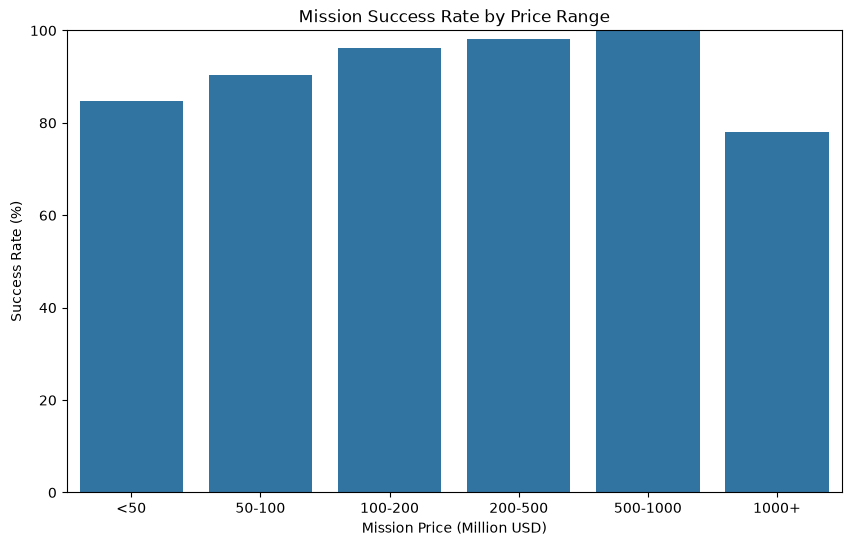

In [112]:
price_bins = [0, 50, 100, 200, 500, 1000, float("inf")]
price_labels = ["<50", "50-100", "100-200", "200-500", "500-1000", "1000+"]
temp = final_data.copy()
temp["Price_Range"] = pd.cut(
    temp["Price_Completed_M"],
    bins=price_bins,
    labels=price_labels
)
success_rate = (
    temp.groupby("Price_Range", observed=True)["Mission_Status"]
    .apply(lambda x: (x == "Success").mean() * 100)
    .reset_index(name="Success_Rate")
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=success_rate,
    x="Price_Range",
    y="Success_Rate"
)
plt.title("Mission Success Rate by Price Range")
plt.xlabel("Mission Price (Million USD)")
plt.ylabel("Success Rate (%)")
plt.ylim(0, 100)
plt.show()

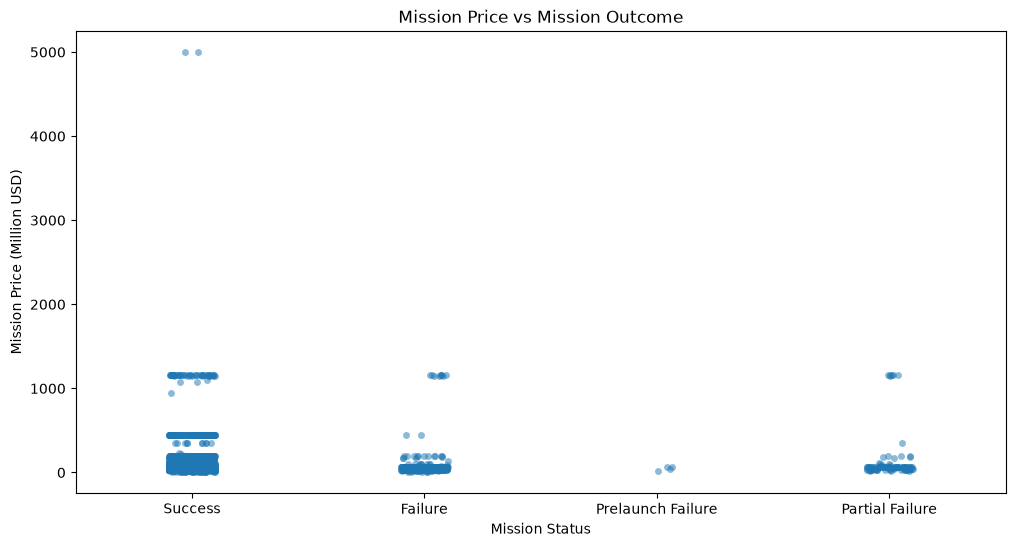

In [113]:
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=final_data,
    x="Mission_Status",
    y="Price_Completed_M",
    alpha=0.5,
    jitter=True
)
plt.title("Mission Price vs Mission Outcome")
plt.xlabel("Mission Status")
plt.ylabel("Mission Price (Million USD)")
plt.show()

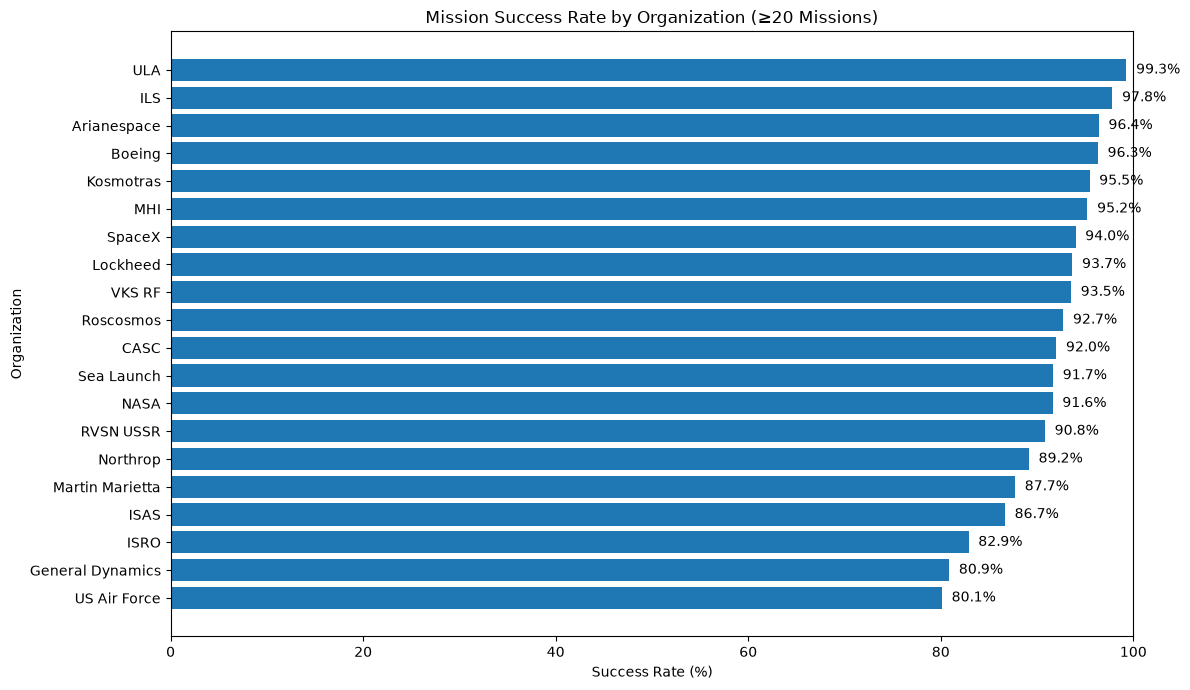

In [114]:
# Success rate by organization for organizations with at least 20 missions

org_success = (
    final_data.groupby("Organisation")
    .agg(
        Total_Missions=("Mission_Status", "count"),
        Successful_Missions=("Mission_Status", lambda x: (x == "Success").sum())
    )
)

# Calculate success rate
org_success["Success_Rate"] = (
    org_success["Successful_Missions"] /
    org_success["Total_Missions"] * 100
)

# Keep organizations with at least 20 missions
org_success_20 = (
    org_success[org_success["Total_Missions"] >= 20]
    .sort_values("Success_Rate", ascending=False)
)

# Plot
plt.figure(figsize=(12, 7))

bars = plt.barh(
    org_success_20.index,
    org_success_20["Success_Rate"]
)

plt.xlabel("Success Rate (%)")
plt.ylabel("Organization")
plt.title("Mission Success Rate by Organization (≥20 Missions)")
plt.xlim(0, 100)
plt.gca().invert_yaxis()

# Add percentage labels
for bar, value in zip(bars, org_success_20["Success_Rate"]):
    plt.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

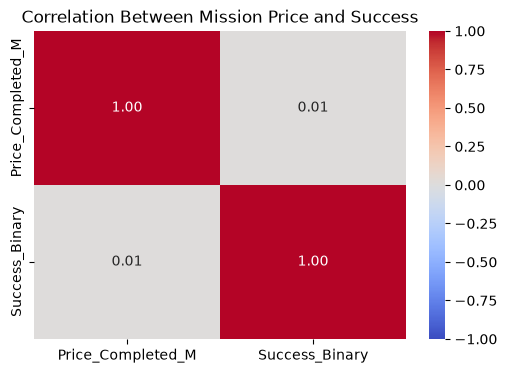

In [115]:
# Convert mission status to binary
final_data["Success_Binary"] = (
    final_data["Mission_Status"] == "Success"
).astype(int)

# Select variables
corr_data = final_data[[
    "Price_Completed_M",
    "Success_Binary"
]].corr()

# Plot heatmap
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Mission Price and Success")
plt.show()

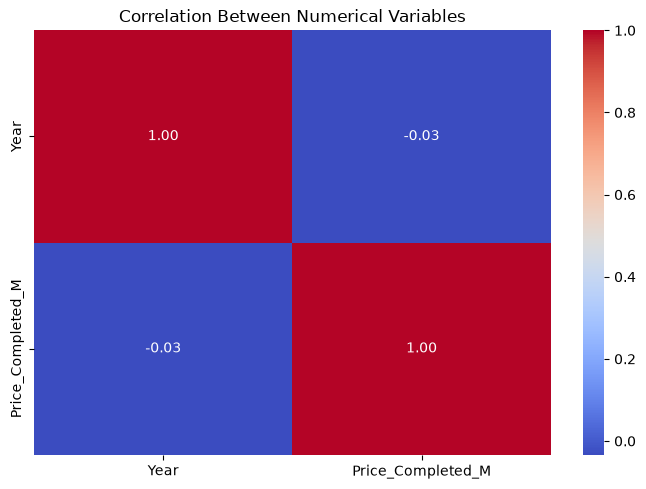

In [116]:
numeric_data = eda_data[
    [
        "Year",
        "Price_Completed_M"
    ]
]
plt.figure(figsize=(7, 5))
sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

In [117]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Missions",
        "Observed Prices",
        "Estimated Prices",
        "Median Mission Cost",
        "Mean Mission Cost",
        "Minimum Mission Cost",
        "Maximum Mission Cost"
    ],
    "Value": [
        len(eda_data),
        (~eda_data["Price_Was_Missing"]).sum(),
        eda_data["Price_Was_Missing"].sum(),
        eda_data["Price_Completed_M"].median(),
        eda_data["Price_Completed_M"].mean(),
        eda_data["Price_Completed_M"].min(),
        eda_data["Price_Completed_M"].max()
    ]
})
eda_summary

,Metric,Value
0,Total Missions,4323.000000
1,Observed Prices,963.000000
2,Estimated Prices,3360.000000
3,Median Mission Cost,62.000000
4,Mean Mission Cost,103.337525
5,Minimum Mission Cost,5.300000
6,Maximum Mission Cost,5000.000000


**3. Multivariate Analysis:**
Analyzes three or more variables simultaneously to understand interactions and patterns among them.

Country
China         float64
France        float64
Kazakhstan    float64
Russia        float64
USA           float64
Yellow Sea    float64
dtype: object


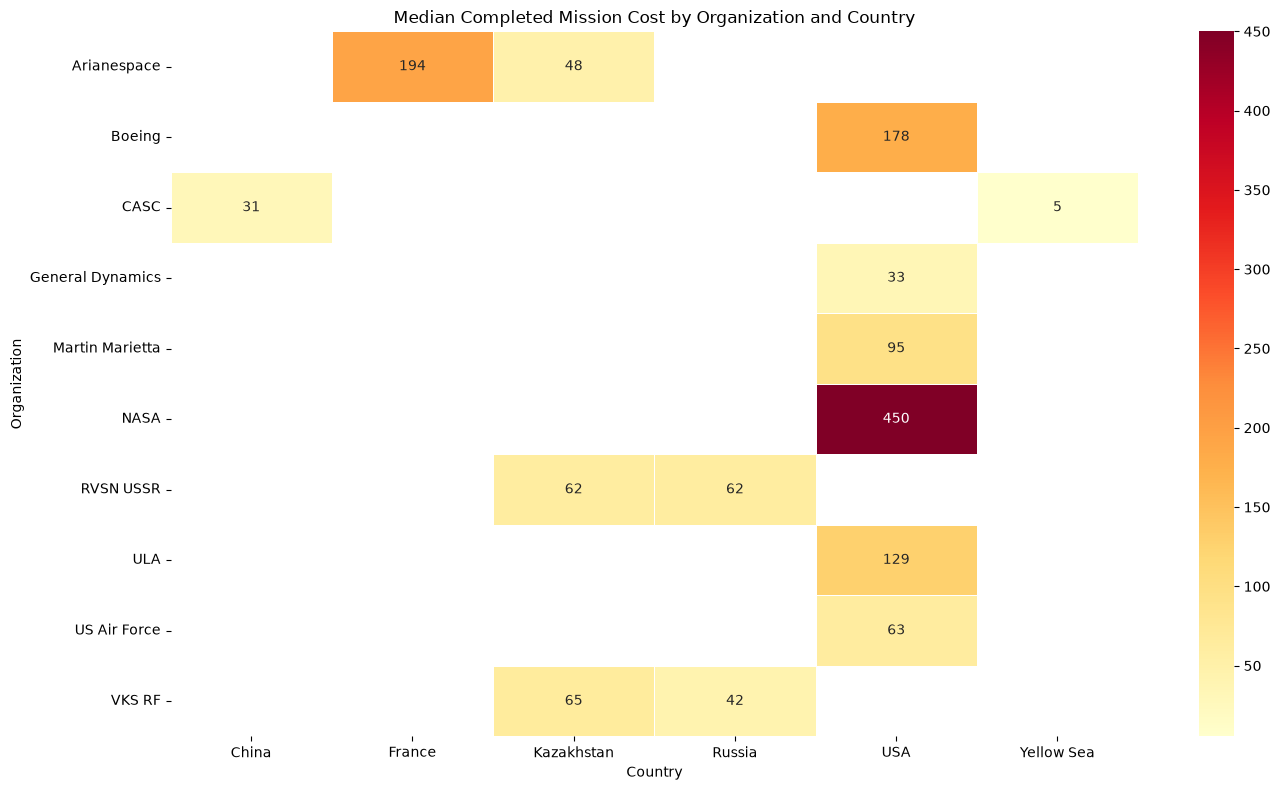

In [118]:
# Organization × Country × Mission Cost
top_orgs = (
    final_data["Organisation"]
    .value_counts()
    .head(10)
    .index
)
org_country_data = final_data[
    final_data["Organisation"].isin(top_orgs)
].copy()
# Create pivot table
pivot_price = org_country_data.pivot_table(
    index="Organisation",
    columns="Country",
    values="Price_Completed_M",
    aggfunc="median"
)
# IMPORTANT: convert pd.NA to regular NumPy NaN
pivot_price = pivot_price.astype("float64")
print(pivot_price.dtypes)
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_price,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Median Completed Mission Cost by Organization and Country")
plt.xlabel("Country")
plt.ylabel("Organization")
plt.tight_layout()
plt.show()

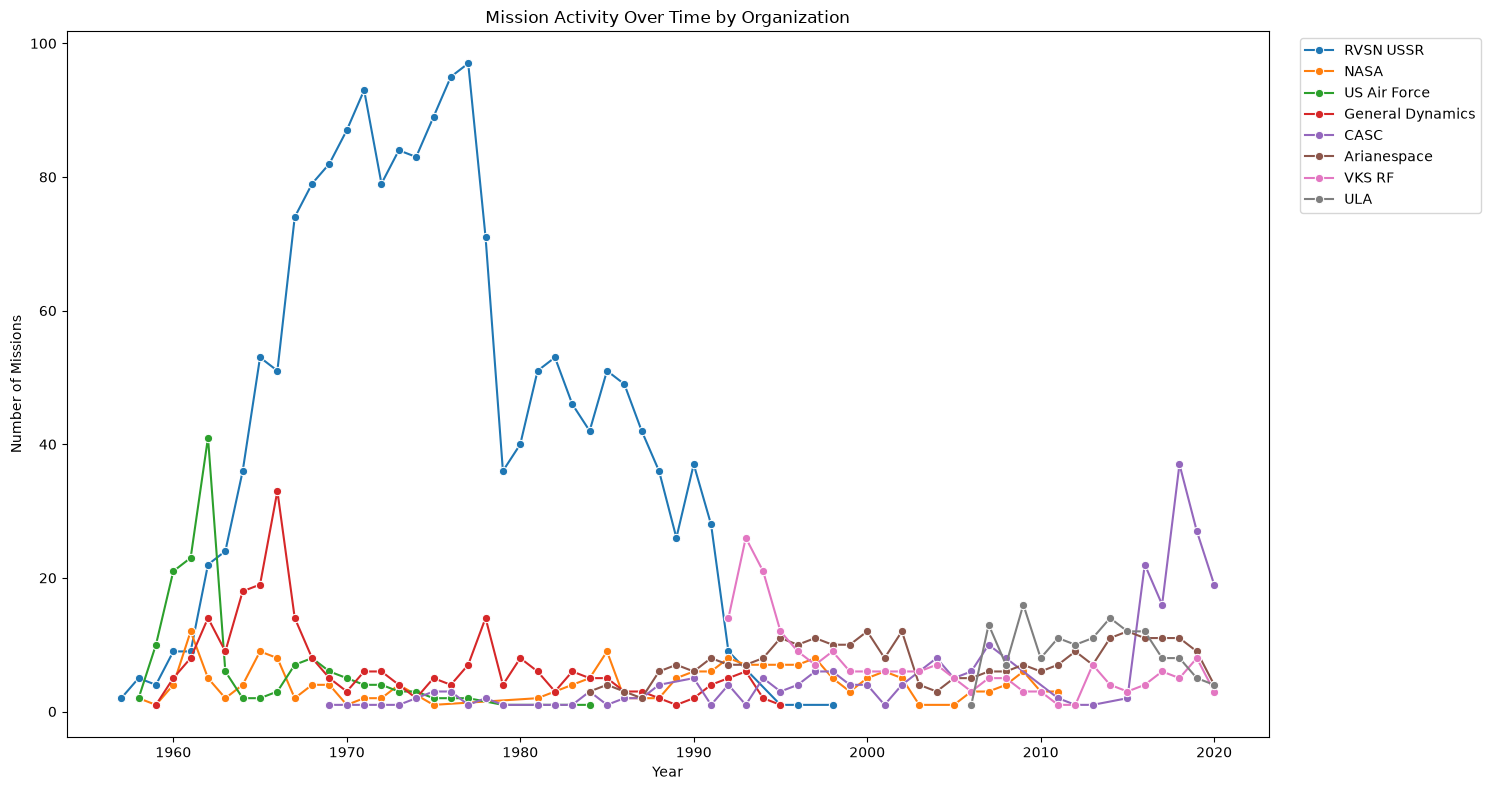

In [119]:
# Year × Organization × Mission Count
top_orgs = (
    final_data["Organisation"]
    .value_counts()
    .head(8)
    .index
)
year_org = (
    final_data[
        final_data["Organisation"].isin(top_orgs)
    ]
    .groupby(["Year", "Organisation"])
    .size()
    .reset_index(name="Mission_Count")
)
plt.figure(figsize=(15, 8))
sns.lineplot(
    data=year_org,
    x="Year",
    y="Mission_Count",
    hue="Organisation",
    marker="o"
)
plt.title("Mission Activity Over Time by Organization")
plt.xlabel("Year")
plt.ylabel("Number of Missions")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()